In [1]:
import functools
import jax
import os
from datetime import datetime
from jax import numpy as jp
import matplotlib.pyplot as plt

from IPython.display import HTML, clear_output

try:
    import brax
except ImportError:
    !pip install git+https://github.com/google/brax.git@main
    clear_output()
    import brax

import flax

import flax.serialization
import pickle

from brax import envs
from brax.training.agents.ppo import train as ppo
from brax.training.agents.sac import train as sac
from brax.io import html, mjcf, model
import torch
import torch.nn as nn
from torch_geometric.nn import GCNConv
if 'COLAB_TPU_ADDR' in os.environ:
    from jax.tools import colab_tpu
    colab_tpu.setup_tpu()







# class WalkerGNN(nn.Module):
#     def __init__(self, input_dim, hidden_dim, output_dim):
#         super(WalkerGNN, self).__init__()
#         self.conv1 = GCNConv(input_dim, hidden_dim)
#         self.conv2 = GCNConv(hidden_dim, output_dim)

#     def forward(self, x, edge_index):
#         x = self.conv1(x, edge_index)
#         x = torch.relu(x)
#         x = self.conv2(x, edge_index)
#         return x

# edge_index = torch.tensor([
#     [0, 1], [1, 2], [2, 3],
#     [3, 4], [4, 5], [5, 0]
# ], dtype=torch.long).t().contiguous()

# # Create GNN model
# gnn_model = WalkerGNN(input_dim=3, hidden_dim=16, output_dim=3)
# optimizer = torch.optim.Adam(gnn_model.parameters(), lr=0.01)
# loss_fn = nn.MSELoss()

# def train_gnn(left_leg_data, right_leg_data):
#     """Train the GNN to learn the symmetry mapping."""
#     for epoch in range(1000):
#         optimizer.zero_grad()
#         output = gnn_model(left_leg_data, edge_index)
#         loss = loss_fn(output, right_leg_data)
#         loss.backward()
#         optimizer.step()
        
#         if epoch % 100 == 0:
#             print(f"Epoch {epoch}, Loss: {loss.item()}")

# # Train GNN (using dummy data for now)
# left_leg_data = torch.rand((6, 3))  # Simulated left leg joint states
# right_leg_data = torch.rand((6, 3))  # Simulated right leg joint states
# train_gnn(left_leg_data, right_leg_data)


In [2]:
#@title Check if MuJoCo installation was successful

# from google.colab import files

import distutils.util
import os
import subprocess
if subprocess.run('nvidia-smi').returncode:
  raise RuntimeError(
      'Cannot communicate with GPU. '
      'Make sure you are using a GPU Colab runtime. '
      'Go to the Runtime menu and select Choose runtime type.')

# Add an ICD config so that glvnd can pick up the Nvidia EGL driver.
# This is usually installed as part of an Nvidia driver package, but the Colab
# kernel doesn't install its driver via APT, and as a result the ICD is missing.
# (https://github.com/NVIDIA/libglvnd/blob/master/src/EGL/icd_enumeration.md)
NVIDIA_ICD_CONFIG_PATH = '/usr/share/glvnd/egl_vendor.d/10_nvidia.json'
if not os.path.exists(NVIDIA_ICD_CONFIG_PATH):
  with open(NVIDIA_ICD_CONFIG_PATH, 'w') as f:
    f.write("""{
    "file_format_version" : "1.0.0",
    "ICD" : {
        "library_path" : "libEGL_nvidia.so.0"
    }
}
""")

# Configure MuJoCo to use the EGL rendering backend (requires GPU)
print('Setting environment variable to use GPU rendering:')
%env MUJOCO_GL=egl

try:
  print('Checking that the installation succeeded:')
  import mujoco
  mujoco.MjModel.from_xml_string('<mujoco/>')
except Exception as e:
  raise e from RuntimeError(
      'Something went wrong during installation. Check the shell output above '
      'for more information.\n'
      'If using a hosted Colab runtime, make sure you enable GPU acceleration '
      'by going to the Runtime menu and selecting "Choose runtime type".')

print('Installation successful.')

# Tell XLA to use Triton GEMM, this improves steps/sec by ~30% on some GPUs
xla_flags = os.environ.get('XLA_FLAGS', '')
xla_flags += ' --xla_gpu_triton_gemm_any=True'
os.environ['XLA_FLAGS'] = xla_flags


Sun Mar 23 23:22:41 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.124.06             Driver Version: 570.124.06     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4090        Off |   00000000:17:00.0 Off |                  Off |
| 30%   35C    P0             52W /  450W |    5148MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import time
import itertools
import numpy as np
from typing import Callable, NamedTuple, Optional, Union, List

print('Installing mediapy:')
# ! command -v ffmpeg >/dev/null || (dnf update && dnf install -y ffmpeg)
# ! pip install -q mediapy
# import mediapy as media
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True, linewidth=100)

Installing mediapy:


In [4]:
#@title Import MuJoCo, MJX, and Brax
from datetime import datetime
from etils import epath
import functools
from IPython.display import HTML
from typing import Any, Dict, Sequence, Tuple, Union
import os
from ml_collections import config_dict


import jax
from jax import numpy as jp
import numpy as np
from flax.training import orbax_utils
from flax import struct
from matplotlib import pyplot as plt
import mediapy as media
from orbax import checkpoint as ocp

import mujoco
from mujoco import mjx

from brax import base
from brax import envs
from brax import math
from brax.base import Base, Motion, Transform
from brax.base import State as PipelineState
from brax.envs.base import Env, PipelineEnv, State
from brax.mjx.base import State as MjxState
from brax.training.agents.ppo import train as ppo
from brax.training.agents.ppo import networks as ppo_networks
from brax.io import html, mjcf, model


In [5]:
xdata, ydata = [], []
times = [datetime.now()]
    
def progress(num_steps, metrics):
    times.append(datetime.now())
    xdata.append(num_steps)
    ydata.append(metrics['eval/episode_reward'])
    clear_output(wait=True)
    plt.plot(xdata, ydata)
    plt.xlabel('# environment steps')
    plt.ylabel('reward per episode')
    plt.show()

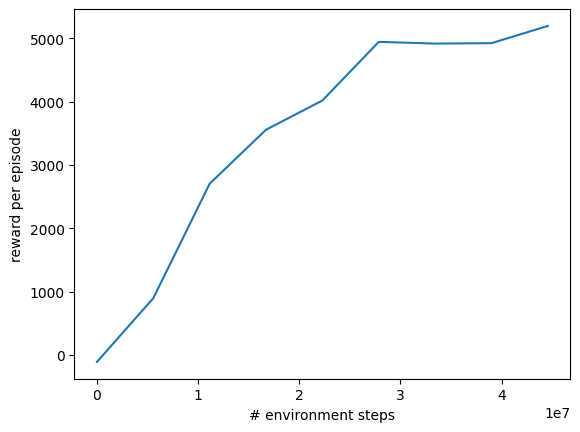

In [ ]:
env_name = 'ant'
backend = 'positional'

env = envs.get_environment(env_name=env_name, backend=backend)
state = jax.jit(env.reset)(rng=jax.random.PRNGKey(seed=0))

def train_walker():
    """Train Walker2D with SAC."""
    train_fn = functools.partial(ppo.train,  num_timesteps=50_000_000, num_evals=10, reward_scaling=10, episode_length=1000, normalize_observations=True, action_repeat=1, unroll_length=5, num_minibatches=32, num_updates_per_batch=4, discounting=0.97, learning_rate=3e-4, entropy_cost=1e-2, num_envs=4096, batch_size=2048, seed=1)
    # train_fn = functools.partial(sac.train, num_timesteps=7_864_320, num_evals=20, reward_scaling=5, 
    #                              episode_length=1000, normalize_observations=True, action_repeat=1, 
    #                              discounting=0.997, learning_rate=6e-4, num_envs=128, batch_size=128, 
    #                              grad_updates_per_step=32, max_devices_per_host=1, 
    #                              max_replay_size=1048576, min_replay_size=8192, seed=1)
    
 
    
    make_inference_fn, params, _ = train_fn(environment=env, progress_fn=progress)
    print(f'Time to train: {times[-1] - times[0]}')
    return make_inference_fn, params



# 训练保存模型

inference_fn, params = train_walker()



model_path = 'trained_params_ant.pkl'
model.save_params(model_path, params)

In [ ]:
env_name = 'walker2d'
backend = 'positional'

env = envs.get_environment(env_name=env_name, backend=backend)
state = jax.jit(env.reset)(rng=jax.random.PRNGKey(seed=0))

def train_walker():
    """Train Walker2D with SAC."""
    train_fn = functools.partial(sac.train, num_timesteps=7_864_320, num_evals=20, reward_scaling=5, 
                                 episode_length=1000, normalize_observations=True, action_repeat=1, 
                                 discounting=0.997, learning_rate=6e-4, num_envs=128, batch_size=128, 
                                 grad_updates_per_step=32, max_devices_per_host=1, 
                                 max_replay_size=1048576, min_replay_size=8192, seed=1)
    
 
    
    make_inference_fn, params, _ = train_fn(environment=env, progress_fn=progress)
    print(f'Time to train: {times[-1] - times[0]}')
    return make_inference_fn, params



# 训练保存模型

inference_fn, params = train_walker()



model_path = 'trained_params.pkl'
model.save_params(model_path, params)


In [7]:
# Save and reload params.
model_path = '/u20/li3658/rl_training/models/test4'
model.save_params(model_path, params)
params = model.load_params(model_path)

inference_fn = inference_fn(params)
jit_inference_fn = jax.jit(inference_fn)

In [8]:
# eval_env = envs.get_environment(env_name)

# jit_reset = jax.jit(eval_env.reset)
# jit_step = jax.jit(eval_env.step)

In [ ]:
#@title Visualizing a trajectory of the learned inference function


jit_env_reset = jax.jit(env.reset)
jit_env_step = jax.jit(env.step)
jit_inference_fn = jax.jit(inference_fn)

rollout = []
rng = jax.random.PRNGKey(seed=1)
state = jit_env_reset(rng=rng)
for _ in range(1000):
  rollout.append(state.pipeline_state)
  act_rng, rng = jax.random.split(rng)
  act, _ = jit_inference_fn(state.obs, act_rng)
  state = jit_env_step(state, act)

html_output = html.render(env.sys.tree_replace({'opt.timestep': env.dt}), rollout)
with open("output_test_ant.html", "w") as f:
    f.write(html_output)
print("Saved visualization as output.html. Open it in a browser.")

# Load the existing RL model

In [10]:
#@title Load Model and Define Inference Function
from brax.training.acme import running_statistics
from brax.training.agents.sac import networks as sac_networks
env_name = 'walker2d'
backend = 'positional'
# create an env with auto-reset
env = envs.create(env_name=env_name, backend=backend)
# normalize_fn = lambda x, y: x

model_path = '/u20/li3658/rl_training/models/test4'
params = model.load_params(model_path)
# sac_network = sac_networks.make_sac_networks(
#         env.observation_size, env.action_size, normalize_fn
#     )
sac_network = sac_networks.make_sac_networks(
        action_size=env.action_size, observation_size=env.observation_size, preprocess_observations_fn=running_statistics.normalize
    )
inference = sac_networks.make_inference_fn(sac_network)
jit_inference_fn = inference(params)

jit_inference_fn = jax.jit(jit_inference_fn)

In [8]:

# 解析 Walker2D 的关节名称
walker2d_joint_names = ['thigh_joint', 'leg_joint', 'foot_joint',
                         'thigh_left_joint', 'leg_left_joint', 'foot_left_joint']

# 关节名称映射（右腿 → 左腿）
joint_mapping = {
    "thigh_joint": "thigh_left_joint",
    "leg_joint": "leg_left_joint",
    "foot_joint": "foot_left_joint",
}

# 计算左右腿的索引
joint_indices = {name: idx for idx, name in enumerate(walker2d_joint_names)}
left_leg_indices = [joint_indices[joint_mapping[joint]] for joint in joint_mapping]
right_leg_indices = [joint_indices[joint] for joint in joint_mapping]


In [ ]:
#@title Visualizing a trajectory of the learned inference function
import jax
import jax.numpy as jnp
# create an env with auto-reset
env = envs.create(env_name=env_name, backend=backend)

jit_env_reset = jax.jit(env.reset)
jit_env_step = jax.jit(env.step)
# jit_inference_fn = jax.jit(inference_fn)
data = []
rollout = []
rng = jax.random.PRNGKey(seed=1)
state = jit_env_reset(rng=rng)
for _ in range(10000):
  rollout.append(state.pipeline_state)
  act_rng, rng = jax.random.split(rng)
  act, _ = jit_inference_fn(state.obs, act_rng)
  state = jit_env_step(state, act)

  # left_leg_data = act[jnp.array(left_leg_indices)]
  # right_leg_data = act[jnp.array(right_leg_indices)]

  left_leg_data = act[:3]
  right_leg_data = act[3:]

  data.append((left_leg_data, right_leg_data))

html_output = html.render(env.sys.tree_replace({'opt.timestep': env.dt}), rollout)
with open("output_test_6.html", "w") as f:
    f.write(html_output)
print("Saved visualization as output.html. Open it in a browser.")

In [11]:


# # 解析 Walker2D 的关节名称
# walker2d_joint_names = ['thigh_joint', 'leg_joint', 'foot_joint',
#                          'thigh_left_joint', 'leg_left_joint', 'foot_left_joint']

# # 关节名称映射（右腿 → 左腿）
# joint_mapping = {
#     "thigh_joint": "thigh_left_joint",
#     "leg_joint": "leg_left_joint",
#     "foot_joint": "foot_left_joint",
# }

# # 计算左右腿的索引
# joint_indices = {name: idx for idx, name in enumerate(walker2d_joint_names)}
# left_leg_indices = [joint_indices[joint_mapping[joint]] for joint in joint_mapping]
# right_leg_indices = [joint_indices[joint] for joint in joint_mapping]


In [ ]:
print(data)

In [33]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# from torch_geometric.nn import GCNConv

# # class WalkerGNN(nn.Module):
# #     def __init__(self, input_dim, hidden_dim, output_dim):
# #         super(WalkerGNN, self).__init__()
# #         self.conv1 = GCNConv(input_dim, hidden_dim)
# #         self.conv2 = GCNConv(hidden_dim, output_dim)

# #     def forward(self, x, edge_index):
# #         """
# #         x: 节点特征 (左右腿合并的输入)
# #         edge_index: 图结构
# #         """
# #         # print(f"GNN Forward - x shape: {x.shape}, edge_index shape: {edge_index.shape}")

# #         x = self.conv1(x, edge_index)
# #         x = F.relu(x)

# #         # print(f"GNN Forward - After conv1, x shape: {x.shape}")

# #         x = self.conv2(x, edge_index)

# #         # print(f"GNN Forward - Final output shape: {x.shape}")
# #         return x

# # # 设定图结构
# # edge_index = torch.tensor([
# #     [0, 1], [1, 2], [2, 0],  # 右腿：thigh_joint → leg_joint → foot_joint
# #     [3, 4], [4, 5], [5, 3],  # 左腿：thigh_left_joint → leg_left_joint → foot_left_joint
# #     [0, 3], [1, 4], [2, 5]   # 对称连接：右腿 → 左腿
# # ], dtype=torch.long).t().contiguous()


# class WalkerGNN(nn.Module):
#     def __init__(self, input_dim, hidden_dim, output_dim):
#         super(WalkerGNN, self).__init__()
#         self.conv1 = GCNConv(input_dim, hidden_dim)
#         self.conv2 = GCNConv(hidden_dim, output_dim)

#     def forward(self, x, edge_index):
#         # print(f"x shape: {x.shape}")  
#         x = self.conv1(x, edge_index)
#         x = torch.relu(x)
#         x = self.conv2(x, edge_index)

#         if x.shape[1] > 3:
#             x = x[:, :3]  # 只保留前三列，避免多余信息
#         return x
# # 设定图结构
# edge_index = torch.tensor([
#     [0, 1], [1, 2], [2, 0],  # 右腿：thigh_joint → leg_joint → foot_joint
#     [3, 4], [4, 5], [5, 3],  # 左腿：thigh_left_joint → leg_left_joint → foot_left_joint
#     [0, 3], [1, 4], [2, 5]   # 对称连接：右腿 → 左腿
# ], dtype=torch.long).t().contiguous()



# # 初始化 GNN
# gnn_model = WalkerGNN(input_dim=3, hidden_dim=16, output_dim=3)
# optimizer = torch.optim.Adam(gnn_model.parameters(), lr=0.01)
# loss_fn = nn.MSELoss()

# Isomorphic Graph Network

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class WalkerGNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(WalkerGNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)  # 第一层全连接
        self.fc2 = nn.Linear(hidden_dim, output_dim) # 输出层

    def forward(self, x):
        x = torch.relu(self.fc1(x))  # 第一层 + ReLU 激活
        x = self.fc2(x)  # 输出层
        return x


In [38]:
class WalkerGNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(WalkerGNN, self).__init__()
        # 使用更深的网络
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)  # 额外层
        self.fc3 = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(0.2)  # 添加dropout防止过拟合
        
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

# Dataset and DataLoader

In [3]:
from torch.utils.data import Dataset, DataLoader

class WalkerDataset(Dataset):
    def __init__(self, data):
        """
        data: List of tuples (left_leg_data, right_leg_data)
        """
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        left_leg, right_leg = self.data[idx]
        # 解除 `read-only` 并转换为 PyTorch Tensor
        left_leg = torch.tensor(np.array(left_leg, dtype=np.float32).copy())
        right_leg = torch.tensor(np.array(right_leg, dtype=np.float32).copy())
        return left_leg, right_leg


In [25]:
batch_size = 32  # 你可以调整 batch_size

# 初始化 Dataset 和 DataLoader
dataset = WalkerDataset(data)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
# dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)



In [ ]:
import torch

# 保存整个 data 列表
torch.save(dataset.data, "/u20/li3658/rl_training/dataset/walker2d_dataset.pth")

print("✅ WalkerDataset 数据已保存！")

# Load the existing WalkerDataset

In [9]:
import torch.serialization
import numpy as np


torch.serialization.add_safe_globals(["jax._src.array._reconstruct_array"])

loaded_data = torch.load("/u20/li3658/rl_training/dataset/walker2d_dataset.pth", weights_only=False)
# 复用已有的 WalkerDataset
dataset = WalkerDataset(loaded_data)
device = torch.device("cuda")
# dataset.to(device)
# 重新创建 DataLoader
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)
# dataloader = DataLoader(dataset, batch_size=32, shuffle=False)


print("✅ WalkerDataset 重新创建成功！")


✅ WalkerDataset 重新创建成功！


In [12]:
datas = []
for data in dataloader:
    datas.append(data)
print(datas)

import pickle
# import numpy as np

# 假设您的数据存储在变量'data'中
# data格式应该是[(left_leg_data, right_leg_data), ...]的列表

# 保存数据
with open('walker_data.pkl', 'wb') as f:  # 注意使用'wb'模式 - 写入二进制
    pickle.dump(datas, f)

print(f"数据已保存至 walker_data.pkl，共 {len(datas)} 个样本")

[[tensor([[-0.9801, -0.1832,  0.6159]]), tensor([[0.1457, 0.9749, 0.3951]])], [tensor([[0.8258, 0.9373, 0.7412]]), tensor([[ 0.9167,  0.7062, -0.9090]])], [tensor([[-0.7191, -0.5669, -0.7354]]), tensor([[ 0.8928,  0.0936, -0.4788]])], [tensor([[ 0.7120, -0.3073, -0.8101]]), tensor([[0.9497, 0.9256, 0.8740]])], [tensor([[-0.8661, -0.2551, -0.7631]]), tensor([[0.9462, 0.6357, 0.8616]])], [tensor([[ 0.7413, -0.6030, -0.7564]]), tensor([[-0.9643,  0.2966,  0.7465]])], [tensor([[-0.8948, -0.5065, -0.8236]]), tensor([[ 0.8686, -0.6769, -0.8063]])], [tensor([[0.9344, 0.7627, 0.1777]]), tensor([[-0.7666,  0.8294,  0.4803]])], [tensor([[ 0.7550, -0.2250,  0.9499]]), tensor([[ 0.5880, -0.9757, -0.8564]])], [tensor([[-0.8552, -0.5476, -0.2851]]), tensor([[0.9751, 0.6246, 0.4296]])], [tensor([[ 0.9760, -0.4853, -0.6418]]), tensor([[0.8314, 0.8295, 0.8082]])], [tensor([[-0.7007,  0.7014,  0.0973]]), tensor([[0.9914, 0.6788, 0.8036]])], [tensor([[-0.6425, -0.3809, -0.0125]]), tensor([[ 0.9743,  0.28

: 

In [ ]:
for left_leg_batch, right_leg_batch in dataloader:
    print(left_leg_batch, right_leg_batch)
    break

In [ ]:
# import torch

# # 定义训练参数
# num_epochs = 500  # 训练轮数
# learning_rate = 0.01

# # 选择设备
# # device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# device = torch.device("cpu")
# # 初始化 GNN 模型
# gnn_model = WalkerGNN(input_dim=3, hidden_dim=16, output_dim=3).to(device)
# optimizer = torch.optim.Adam(gnn_model.parameters(), lr=learning_rate)
# loss_fn = nn.MSELoss()

# # 训练循环
# for epoch in range(num_epochs):
#     total_loss = 0.0
#     for left_leg_batch, right_leg_batch in dataloader:
#         # 发送到 GPU 或 CPU
#         left_leg_batch = left_leg_batch.to(device)
#         right_leg_batch = right_leg_batch.to(device)

#         # 计算预测的右腿动作
#         optimizer.zero_grad()
#         predicted_right_leg = gnn_model(left_leg_batch, edge_index.to(device))

#         # 计算 MSE Loss
#         loss = loss_fn(predicted_right_leg, right_leg_batch)
#         loss.backward()
#         optimizer.step()

#         total_loss += loss.item()

#     # 每 50 轮打印一次损失
#     if epoch % 50 == 0:
#         print(f'Epoch {epoch}, Loss: {total_loss / len(dataloader)}')

# print("✅ 训练完成！")


In [ ]:
# 初始化模型
gnn_model = WalkerGNN(input_dim=3, hidden_dim=16, output_dim=3)
optimizer = torch.optim.Adam(gnn_model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()
device = torch.device("cuda")
gnn_model.to(device)

In [48]:
def split_dataset(dataset, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    """
    将数据集划分为训练集、验证集和测试集
    """
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-5, "比例之和必须为1"
    
    dataset_size = len(dataset)
    indices = list(range(dataset_size))
    
    # 打乱索引
    np.random.shuffle(indices)
    
    # 计算分割点
    train_split = int(np.floor(train_ratio * dataset_size))
    val_split = int(np.floor((train_ratio + val_ratio) * dataset_size))
    
    # 创建数据加载器
    train_indices = indices[:train_split]
    val_indices = indices[train_split:val_split]
    test_indices = indices[val_split:]
    
    # 使用SubsetRandomSampler创建数据加载器
    from torch.utils.data import DataLoader, SubsetRandomSampler
    
    train_sampler = SubsetRandomSampler(train_indices)
    val_sampler = SubsetRandomSampler(val_indices)
    test_sampler = SubsetRandomSampler(test_indices)
    
    train_loader = DataLoader(dataset, batch_size=32, sampler=train_sampler)
    val_loader = DataLoader(dataset, batch_size=32, sampler=val_sampler)
    test_loader = DataLoader(dataset, batch_size=32, sampler=test_sampler)
    
    return train_loader, val_loader, test_loader

In [49]:
# 导入必要的库
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import ReduceLROnPlateau

# 假设您已经有了dataset
# 划分数据集
train_loader, val_loader, test_loader = split_dataset(dataset)

In [46]:
def validate(model, val_loader, loss_fn, device):
    """
    验证模型性能
    """
    model.eval()  # 设置为评估模式
    total_loss = 0.0
    num_batches = 0
    
    with torch.no_grad():  # 禁用梯度计算
        for left_leg_data, right_leg_data in val_loader:
            # 将数据移到GPU
            left_leg_data = left_leg_data.to(device)
            right_leg_data = right_leg_data.to(device)
            
            # 前向传播
            output = model(left_leg_data)
            
            # 计算损失
            loss = loss_fn(output, right_leg_data)
            total_loss += loss.item()
            num_batches += 1
    
    # 计算平均损失
    avg_loss = total_loss / num_batches
    
    model.train()  # 恢复训练模式
    return avg_loss

In [47]:
def test(model, test_loader, device):
    """
    测试模型性能并计算多种指标
    """
    model.eval()  # 设置为评估模式
    all_preds = []
    all_targets = []
    
    with torch.no_grad():  # 禁用梯度计算
        for left_leg_data, right_leg_data in test_loader:
            # 将数据移到GPU
            left_leg_data = left_leg_data.to(device)
            right_leg_data = right_leg_data.to(device)
            
            # 前向传播
            output = model(left_leg_data)
            
            # 收集预测和目标
            all_preds.append(output.cpu().numpy())
            all_targets.append(right_leg_data.cpu().numpy())
    
    # 转换为numpy数组
    all_preds = np.concatenate(all_preds, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)
    
    # 计算各种指标
    mse = np.mean((all_preds - all_targets) ** 2)
    mae = np.mean(np.abs(all_preds - all_targets))
    rmse = np.sqrt(mse)
    
    # 计算关节角度误差（假设数据代表角度）
    joint_mse = np.mean((all_preds - all_targets) ** 2, axis=0)
    joint_mae = np.mean(np.abs(all_preds - all_targets), axis=0)
    
    print("测试结果:")
    print(f"整体 MSE: {mse:.6f}")
    print(f"整体 MAE: {mae:.6f}")
    print(f"整体 RMSE: {rmse:.6f}")
    print("\n各关节误差:")
    for i in range(len(joint_mse)):
        print(f"关节 {i}: MSE = {joint_mse[i]:.6f}, MAE = {joint_mae[i]:.6f}")
    
    return {
        'mse': mse,
        'mae': mae,
        'rmse': rmse,
        'joint_mse': joint_mse,
        'joint_mae': joint_mae,
        'predictions': all_preds,
        'targets': all_targets
    }

/u20/li3658/miniconda3/envs/zed/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 0, Train Loss: 0.408975, Val Loss: 0.350898
Grad norm of fc1.weight: 0.08476798981428146
Grad norm of fc1.bias: 0.05386430025100708
Grad norm of fc2.weight: 0.15565121173858643
Grad norm of fc2.bias: 0.08241688460111618
Grad norm of fc3.weight: 0.16750533878803253
Grad norm of fc3.bias: 0.17096944153308868
Epoch 100, Train Loss: 0.324935, Val Loss: 0.315716
Epoch 200, Train Loss: 0.323522, Val Loss: 0.314893
Epoch 300, Train Loss: 0.323751, Val Loss: 0.314697
Epoch 400, Train Loss: 0.323095, Val Loss: 0.314055
Epoch 500, Train Loss: 0.324446, Val Loss: 0.313847
Epoch 600, Train Loss: 0.323496, Val Loss: 0.313519
Epoch 700, Train Loss: 0.322845, Val Loss: 0.313719
Epoch 800, Train Loss: 0.324627, Val Loss: 0.313683
Epoch 900, Train Loss: 0.322656, Val Loss: 0.313744
Epoch 1000, Train Loss: 0.322915, Val Loss: 0.313932
Grad norm of fc1.weight: 0.23325775563716888
Grad norm of fc1.bias: 0.1691821962594986
Grad norm of fc2.weight: 0.1222592145204544
Grad norm of fc2.bias: 0.125958859

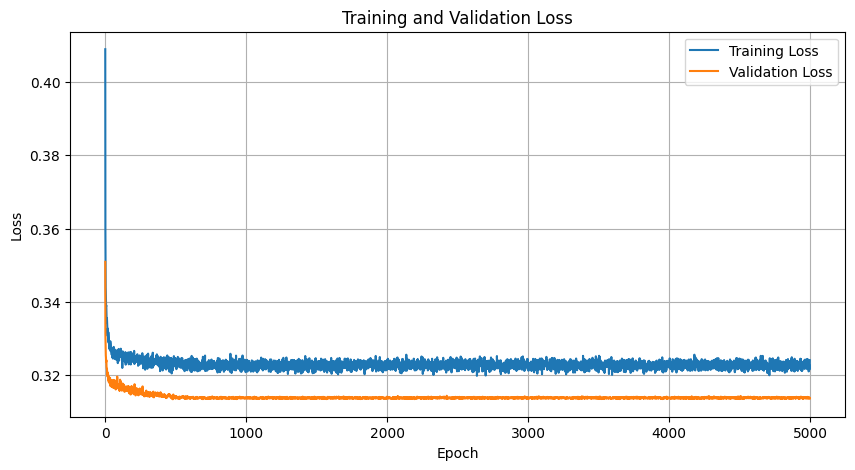


=== 最终模型评估 ===
测试结果:
整体 MSE: 0.314083
整体 MAE: 0.468894
整体 RMSE: 0.560431

各关节误差:
关节 0: MSE = 0.312819, MAE = 0.459927
关节 1: MSE = 0.275865, MAE = 0.429110
关节 2: MSE = 0.353565, MAE = 0.517645
模型已保存到 walker_gnn_model.pth


In [50]:
# 导入必要的库
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import ReduceLROnPlateau

# 假设您已经有了dataset
# 划分数据集
train_loader, val_loader, test_loader = split_dataset(dataset)

# 初始化模型
gnn_model = WalkerGNN(input_dim=3, hidden_dim=16, output_dim=3)
optimizer = torch.optim.RMSprop(gnn_model.parameters(), lr=0.001, alpha=0.9)
loss_fn = nn.MSELoss()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gnn_model.to(device)
gnn_model.train()

# 添加学习率调度器
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=50, verbose=True)

# 记录训练和验证损失
train_losses = []
val_losses = []

# 训练循环
for epoch in range(5000):
    epoch_loss = 0.0
    num_batches = 0
    
    # 训练一个周期
    for left_leg_data, right_leg_data in train_loader:
        optimizer.zero_grad()
        
        # 将数据移到GPU
        left_leg_data = left_leg_data.to(device)
        right_leg_data = right_leg_data.to(device)
        
        # 前向传播
        output = gnn_model(left_leg_data)
        
        # 计算损失
        loss = loss_fn(output, right_leg_data)
        epoch_loss += loss.item()
        num_batches += 1
        
        # 反向传播和优化
        loss.backward()
        optimizer.step()
    
    # 计算平均训练损失
    avg_train_loss = epoch_loss / num_batches
    train_losses.append(avg_train_loss)
    
    # 在验证集上评估
    val_loss = validate(gnn_model, val_loader, loss_fn, device)
    val_losses.append(val_loss)
    
    # 更新学习率
    scheduler.step(val_loss)
    
    # 打印进度
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Train Loss: {avg_train_loss:.6f}, Val Loss: {val_loss:.6f}")
        
        # 检查梯度是否健康（可选）
        if epoch % 1000 == 0:
            for name, param in gnn_model.named_parameters():
                if param.grad is not None:
                    grad_norm = param.grad.norm().item()
                    print(f"Grad norm of {name}: {grad_norm}")

# 绘制损失曲线
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.savefig('loss_curves.png')
plt.show()

# 测试模型
print("\n=== 最终模型评估 ===")
test_results = test(gnn_model, test_loader, device)

# 保存模型
torch.save({
    'model_state_dict': gnn_model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses,
    'val_losses': val_losses,
    'test_results': test_results
}, 'walker_gnn_model.pth')
print("模型已保存到 walker_gnn_model.pth")

In [ ]:
# 初始化模型
gnn_model = WalkerGNN(input_dim=3, hidden_dim=16, output_dim=3)
# optimizer = torch.optim.Adam(gnn_model.parameters(), lr=0.001)
optimizer = torch.optim.RMSprop(gnn_model.parameters(), lr=0.001, alpha=0.9)
loss_fn = nn.MSELoss()
device = torch.device("cuda")
gnn_model.to(device)
gnn_model.train()
# 训练循环
for epoch in range(5000):
    for left_leg_data, right_leg_data in dataloader:
        optimizer.zero_grad()

        # # 确保输入数据是 (1,3)
        # left_leg_tensor = torch.tensor(left_leg_data, dtype=torch.float32).unsqueeze(0).to(device)  
        # right_leg_tensor = torch.tensor(right_leg_data, dtype=torch.float32).unsqueeze(0).to(device)  

        # 计算 GNN 输出
        output = gnn_model(left_leg_data.to(device))  

        # 计算损失
        loss = loss_fn(output, right_leg_data.to(device))
        loss.backward()
        optimizer.step()
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")


In [ ]:
# 初始化模型
gnn_model = WalkerGNN(input_dim=3, hidden_dim=16, output_dim=3)
optimizer = torch.optim.Adam(gnn_model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()
device = torch.device("cuda")
gnn_model.to(device)
gnn_model.train()
# 训练循环
for epoch in range(5000):
    for left_leg_data, right_leg_data in dataloader:
        optimizer.zero_grad()

        # 确保输入数据是 (1,3)
        left_leg_tensor = torch.tensor(left_leg_data, dtype=torch.float32).unsqueeze(0).to(device)  
        right_leg_tensor = torch.tensor(right_leg_data, dtype=torch.float32).unsqueeze(0).to(device)  

        # 计算 GNN 输出
        output = gnn_model(left_leg_tensor)  

        # 计算损失
        loss = loss_fn(output, right_leg_tensor)
        loss.backward()
        optimizer.step()
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")


In [ ]:
import torch

# 指定保存路径
save_path = "/u20/li3658/rl_training/gnn_model/gnn_model.pth"

# 保存模型参数
torch.save(gnn_model.state_dict(), save_path)
print(f"✅ 模型已保存到 {save_path}")

In [11]:
import torch.nn.functional as F

class EnhancedWalkerGNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout_rate=0.2):
        super(EnhancedWalkerGNN, self).__init__()
        # 更深更宽的网络
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim*2)
        self.bn2 = nn.BatchNorm1d(hidden_dim*2)
        self.fc3 = nn.Linear(hidden_dim*2, hidden_dim)
        self.bn3 = nn.BatchNorm1d(hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout_rate)
        
        # 添加残差连接
        self.shortcut = nn.Linear(input_dim, hidden_dim)
        
        # 权重初始化
        self._initialize_weights()
        
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='leaky_relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
        
    def forward(self, x):
        # 主路径
        main = F.leaky_relu(self.bn1(self.fc1(x)), negative_slope=0.1)
        main = self.dropout(main)
        main = F.leaky_relu(self.bn2(self.fc2(main)), negative_slope=0.1)
        main = self.dropout(main)
        main = F.leaky_relu(self.bn3(self.fc3(main)), negative_slope=0.1)
        
        # 残差连接
        shortcut = F.leaky_relu(self.shortcut(x), negative_slope=0.1)
        
        # 合并
        combined = main + shortcut
        output = self.fc4(combined)
        
        return output

In [12]:

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gnn_model = EnhancedWalkerGNN(input_dim=3, hidden_dim=32, output_dim=3)
# **加载已保存的权重**
# device  = torch.device("cpu")

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
save_path = "/u20/li3658/rl_training/walker_training_results"
checkpoint = torch.load(os.path.join(save_path, 'best_model.pth'))
gnn_model.load_state_dict(checkpoint['model_state_dict'])
gnn_model.eval()


EnhancedWalkerGNN(
  (fc1): Linear(in_features=3, out_features=32, bias=True)
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=32, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (bn3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc4): Linear(in_features=32, out_features=3, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (shortcut): Linear(in_features=3, out_features=32, bias=True)
)

In [ ]:
# **加载已保存的权重**
# device  = torch.device("cpu")

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
save_path = "/u20/li3658/rl_training/gnn_model/gnn_model.pth"
gnn_model.load_state_dict(torch.load(save_path, map_location=device))
gnn_model.eval()


In [ ]:
# # 首先确保您有完整的关节映射定义（图一中的内容）
# walker2d_joint_names = ['thigh_joint', 'leg_joint', 'foot_joint', 
#                         'thigh_left_joint', 'leg_left_joint', 'foot_left_joint']

# # 关节名称映射 (右腿 → 左腿)
# joint_mapping = {
#     "thigh_joint": "thigh_left_joint",
#     "leg_joint": "leg_left_joint",
#     "foot_joint": "foot_left_joint",
# }

# # 计算左右腿的索引
# joint_indices = {name: idx for idx, name in enumerate(walker2d_joint_names)}
# left_leg_indices = [joint_indices[joint_mapping[joint]] for joint in joint_mapping]
# right_leg_indices = [joint_indices[joint] for joint in joint_mapping]

# # 然后修改您的推理循环
# for _ in range(1000):
#     # 保存当前状态
#     rollout.append(state.pipeline_state)
    
#     # 分割RNG
#     act_rng, rng = jax.random.split(rng)
    
#     # 获取原始动作
#     act, _ = jit_inference_fn(state.obs, act_rng)
    
#     # 提取左腿数据 - 这是GNN模型的输入
#     left_leg_data = act[jnp.array(left_leg_indices)]
    
#     # 将左腿数据转换为PyTorch张量
#     left_leg_tensor = torch.tensor(np.array(left_leg_data).copy(), dtype=torch.float32).to(device)
    
#     # 用GNN模型预测右腿数据
#     right_leg_tensor = gnn_model(left_leg_tensor)
    
#     # 创建一个新动作，包含原始左腿数据和GNN预测的右腿数据
#     modified_act = np.array(act).copy()  # 复制原始动作
    
#     # 用GNN预测的右腿数据替换原始右腿数据
#     modified_act[right_leg_indices] = right_leg_tensor.cpu().detach().numpy()
    
#     # 记录左腿和右腿数据（原始数据收集方式）
#     data.append([
#         left_leg_tensor.cpu().detach().numpy(),
#         right_leg_tensor.cpu().detach().numpy()
#     ])
    
#     # 使用修改后的动作更新环境状态
#     state = jit_env_step(state, jnp.array(modified_act))
    
#     # 再次保存更新后的状态
#     rollout.append(state.pipeline_state)

In [13]:
#@title Visualizing a trajectory of the learned inference function
import jax
import jax.numpy as jnp
# create an env with auto-reset

env_name = 'walker2d'
backend = 'positional'
env = envs.create(env_name=env_name, backend=backend)

jit_env_reset = jax.jit(env.reset)
jit_env_step = jax.jit(env.step)
# jit_inference_fn = jax.jit(inference_fn)
data = []
rollout = []
rng = jax.random.PRNGKey(seed=1)
gnn_model.to(device)
gnn_model.eval()
state = jit_env_reset(rng=rng)
for _ in range(1000):
    rollout.append(state.pipeline_state)
    act_rng, rng = jax.random.split(rng)
    act, _ = jit_inference_fn(state.obs, act_rng)
    state = jit_env_step(state, act)
    
    # left_leg_data = act[jnp.array(left_leg_indices)]
    left_leg_data = act[:3]

    # 添加批次维度以防BatchNorm问题
    left_leg_tensor = torch.tensor(np.array(left_leg_data).copy(), dtype=torch.float32).unsqueeze(0).to(device)

    right_leg_tensor = gnn_model(left_leg_tensor) 
    
    # 确保形状正确
    action = np.concatenate([
        left_leg_tensor.cpu().detach().numpy().squeeze(), 
        right_leg_tensor.cpu().detach().numpy().squeeze()
    ])  
    
    # 使用元组而不是列表，并移除多余维度
    data.append((
        left_leg_tensor.cpu().detach().numpy().squeeze(), 
        right_leg_tensor.cpu().detach().numpy().squeeze()
    ))
    
    state = jax.jit(env.step)(state, jnp.array(action))
    rollout.append(state.pipeline_state)

print("data:", data[0])  # 只打印第一个样本查看格式

html_output = html.render(env.sys.tree_replace({'opt.timestep': env.dt}), rollout)
with open("output_test_7.html", "w") as f:
    f.write(html_output)
print("Saved visualization as output.html. Open it in a browser.")

data: (array([-0.888,  0.243,  0.985], dtype=float32), array([-0.344, -0.335,  0.488], dtype=float32))
Saved visualization as output.html. Open it in a browser.


: 

In [ ]:
#@title Visualizing a trajectory of the learned inference function
import jax
import jax.numpy as jnp
# create an env with auto-reset

env_name = 'walker2d'
backend = 'positional'
env = envs.create(env_name=env_name, backend=backend)

jit_env_reset = jax.jit(env.reset)
jit_env_step = jax.jit(env.step)
# jit_inference_fn = jax.jit(inference_fn)
data = []
rollout = []
rng = jax.random.PRNGKey(seed=1)
state = jit_env_reset(rng=rng)
for _ in range(1000):
    rollout.append(state.pipeline_state)
    act_rng, rng = jax.random.split(rng)
    act, _ = jit_inference_fn(state.obs, act_rng)
    state = jit_env_step(state, act)
    
    left_leg_data = act[jnp.array(left_leg_indices)]

    # left_leg_tensor = torch.tensor(left_leg_data, dtype=torch.float32)
    left_leg_tensor = torch.tensor(np.array(left_leg_data).copy(), dtype=torch.float32).to(device)

    right_leg_tensor = gnn_model(left_leg_tensor) 
    # action = np.concatenate([left_leg_tensor.detach().numpy(), right_leg_tensor.detach().numpy()])
    action = np.concatenate([
    left_leg_tensor.cpu().detach().numpy(), 
    right_leg_tensor.cpu().detach().numpy()
    ])  
    # data.append([left_leg_tensor.detach().numpy(), right_leg_tensor.detach().numpy()])
    data.append([
    left_leg_tensor.cpu().detach().numpy(), 
    right_leg_tensor.cpu().detach().numpy()
    ])
    state = jax.jit(env.step)(state, jnp.array(action))
    rollout.append(state.pipeline_state)

# print("rollout:", rollout)

print("data:", data)

html_output = html.render(env.sys.tree_replace({'opt.timestep': env.dt}), rollout)
with open("output_test_5.html", "w") as f:
    f.write(html_output)
print("Saved visualization as output.html. Open it in a browser.")

In [ ]:
#@title Visualizing a trajectory of the learned inference function
import jax
import jax.numpy as jnp
# create an env with auto-reset
env = envs.create(env_name=env_name, backend=backend)

jit_env_reset = jax.jit(env.reset)
jit_env_step = jax.jit(env.step)
# jit_inference_fn = jax.jit(inference_fn)
data = []
rollout = []
rng = jax.random.PRNGKey(seed=1)
state = jit_env_reset(rng=rng)
for _ in range(1000):
  rollout.append(state.pipeline_state)
  act_rng, rng = jax.random.split(rng)
  act, _ = jit_inference_fn(state.obs, act_rng)
  state = jit_env_step(state, act)

  left_leg_data = act[jnp.array(left_leg_indices)]
  right_leg_data = act[jnp.array(right_leg_indices)]

  data.append((left_leg_data, right_leg_data))

html_output = html.render(env.sys.tree_replace({'opt.timestep': env.dt}), rollout)
with open("output_test_5.html", "w") as f:
    f.write(html_output)
print("Saved visualization as output.html. Open it in a browser.")

In [ ]:

# 随机生成左腿的输入
print("Edge index max:", edge_index.max().item())
if torch.cuda.is_available():
    print("GPU is available")

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

gnn_model.to(device)
test_left_leg_action = torch.tensor([[0.1, -0.2, 0.05]], dtype=torch.float32).to(device)
# print("Input tensor shape:", test_left_leg_action.shape)

test_left_leg_action = test_left_leg_action.repeat(32, 1)  # 让输入匹配 batch size
predicted_right_leg_action = gnn_model(test_left_leg_action, edge_index.to(device))

# 输出预测结果
print("Predicted Right Leg Action:", predicted_right_leg_action.cpu().detach().numpy())

In [ ]:
#@title Visualizing a trajectory of the learned inference function
import jax
import jax.numpy as jnp
# create an env with auto-reset
env = envs.create(env_name=env_name, backend=backend)

jit_env_reset = jax.jit(env.reset)
jit_env_step = jax.jit(env.step)
# jit_inference_fn = jax.jit(inference_fn)
data = []
rollout = []
rng = jax.random.PRNGKey(seed=1)
state = jit_env_reset(rng=rng)
for _ in range(1000):
  rollout.append(state.pipeline_state)
  act_rng, rng = jax.random.split(rng)
  act, _ = jit_inference_fn(state.obs, act_rng)
  state = jit_env_step(state, act)

  left_leg_data = act[jnp.array(left_leg_indices)]
  # right_leg_data = act[jnp.array(right_leg_indices)]
  right_leg_data = gnn_model(left_leg_data, edge_index.to(device))
  print("left_leg_data:", left_leg_data, "right_leg_data:", right_leg_data)

  data.append((left_leg_data, right_leg_data))

html_output = html.render(env.sys.tree_replace({'opt.timestep': env.dt}), rollout)
with open("output_test_5.html", "w") as f:
    f.write(html_output)
print("Saved visualization as output.html. Open it in a browser.")

In [47]:
# import numpy as np
# import torch

# def collate_fn(batch):
#     """
#     batch 是一个列表，其中每个元素是 (left_leg, right_leg)
#     """
#     left_batch = [torch.tensor(np.array(left, dtype=np.float32).copy()) for left, _ in batch]
#     right_batch = [torch.tensor(np.array(right, dtype=np.float32).copy()) for _, right in batch]

#     # 组合成 Tensor
#     left_batch = torch.stack(left_batch)
#     right_batch = torch.stack(right_batch)
#     return left_batch, right_batch


In [ ]:
# 获取一个 batch
for left_leg_batch, right_leg_batch in dataloader:
    print(f"Left Leg Batch Shape: {left_leg_batch.shape}")  # 形状应为 (batch_size, 3)
    print(f"Right Leg Batch Shape: {right_leg_batch.shape}")  # 形状应为 (batch_size, 3)
    break  # 只打印一次

In [ ]:
import torch

# 将数据转换为 PyTorch Tensor 并保存
left_leg_data = torch.stack([torch.tensor(left, dtype=torch.float32) for left, _ in data])
right_leg_data = torch.stack([torch.tensor(right, dtype=torch.float32) for _, right in data])

# 保存数据到文件
torch.save((left_leg_data, right_leg_data), "walker2d_dataset.pth")
print("✅ 数据保存成功！")

In [51]:
# 首先检查任务本身是否有意义
def analyze_data_relationship(dataset):
    """分析左右腿数据的内在关系"""
    all_lefts = []
    all_rights = []
    
    # 收集所有数据
    for left, right in dataset:
        all_lefts.append(left.numpy())
        all_rights.append(right.numpy())
    
    all_lefts = np.vstack(all_lefts)
    all_rights = np.vstack(all_rights)
    
    # 计算相关性
    correlations = []
    for i in range(all_lefts.shape[1]):
        for j in range(all_rights.shape[1]):
            corr = np.corrcoef(all_lefts[:, i], all_rights[:, j])[0, 1]
            correlations.append((i, j, corr))
    
    # 按相关性排序
    correlations.sort(key=lambda x: abs(x[2]), reverse=True)
    
    print("左右腿关节角度相关性分析:")
    for i, j, corr in correlations[:5]:
        print(f"左腿关节{i} 与 右腿关节{j}: 相关系数 = {corr:.4f}")
    
    # 计算理论上的最佳线性预测MSE
    from sklearn.linear_model import LinearRegression
    reg = LinearRegression().fit(all_lefts, all_rights)
    predictions = reg.predict(all_lefts)
    linear_mse = np.mean((predictions - all_rights) ** 2)
    
    print(f"\n最佳线性模型MSE: {linear_mse:.6f}")
    print(f"当前神经网络MSE: ~0.31")
    
    return linear_mse

In [ ]:
class EnhancedWalkerGNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout_rate=0.2):
        super(EnhancedWalkerGNN, self).__init__()
        # 更深更宽的网络
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim*2)
        self.bn2 = nn.BatchNorm1d(hidden_dim*2)
        self.fc3 = nn.Linear(hidden_dim*2, hidden_dim)
        self.bn3 = nn.BatchNorm1d(hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout_rate)
        
        # 添加残差连接
        self.shortcut = nn.Linear(input_dim, hidden_dim)
        
    def forward(self, x):
        # 主路径
        main = F.leaky_relu(self.bn1(self.fc1(x)), negative_slope=0.1)
        main = self.dropout(main)
        main = F.leaky_relu(self.bn2(self.fc2(main)), negative_slope=0.1)
        main = self.dropout(main)
        main = F.leaky_relu(self.bn3(self.fc3(main)), negative_slope=0.1)
        
        # 残差连接
        shortcut = F.leaky_relu(self.shortcut(x), negative_slope=0.1)
        
        # 合并
        combined = main + shortcut
        output = self.fc4(combined)
        
        return output

In [ ]:
# 使用周期性学习率+重启
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

# 初始化模型与优化器
model = EnhancedWalkerGNN(input_dim=3, hidden_dim=32, output_dim=3)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.005, weight_decay=1e-4)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=100, T_mult=2, eta_min=1e-5)

# 训练循环改进
best_val_loss = float('inf')
patience = 200
no_improve = 0

for epoch in range(5000):
    # 训练步骤
    model.train()
    train_loss = 0.0
    
    for left_leg, right_leg in train_loader:
        optimizer.zero_grad()
        
        # 数据增强 - 添加小随机噪声帮助逃离局部最小值
        if epoch < 1000:  # 只在早期训练阶段使用
            noise = torch.randn_like(left_leg) * 0.01
            left_leg = left_leg + noise
            
        # 转移到设备并前向传播
        left_leg = left_leg.to(device)
        right_leg = right_leg.to(device)
        
        output = model(left_leg)
        loss = loss_fn(output, right_leg)
        
        # 反向传播与优化
        loss.backward()
        
        # 梯度重缩放 - 防止极小更新
        if epoch < 500:  # 早期训练阶段
            for p in model.parameters():
                if p.grad is not None:
                    p.grad = p.grad * 1.5  # 放大梯度
        
        optimizer.step()
        scheduler.step(epoch + batch_idx / len(train_loader))
        
        train_loss += loss.item()
    
    # 验证步骤
    val_loss = validate(model, val_loader, loss_fn, device)
    
    # 早停与学习率重置
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        no_improve += 1
        
    if no_improve > patience:
        print(f"重置优化器，当前学习率: {optimizer.param_groups[0]['lr']:.6f}")
        optimizer = torch.optim.AdamW(model.parameters(), lr=0.01)
        scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=100, T_mult=2, eta_min=1e-5)
        no_improve = 0

In [ ]:
# 重新处理数据集
class ImprovedWalkerDataset(Dataset):
    def __init__(self, data):
        self.data = data
        
        # 收集所有数据
        all_data = []
        for left, right in data:
            all_data.append(left)
            all_data.append(right)
        all_data = np.vstack(all_data)
        
        # 计算更稳健的统计量
        self.median = np.median(all_data, axis=0)
        self.q75 = np.percentile(all_data, 75, axis=0)
        self.q25 = np.percentile(all_data, 25, axis=0)
        self.iqr = self.q75 - self.q25
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        left, right = self.data[idx]
        
        # 使用稳健的标准化方法
        left_normalized = (left - self.median) / (self.iqr + 1e-8)
        right_normalized = (right - self.median) / (self.iqr + 1e-8)
        
        return left_normalized, right_normalized

In [ ]:
def analyze_predictions(model, test_loader, device):
    """详细分析预测结果，寻找模型瓶颈"""
    model.eval()
    all_preds = []
    all_targets = []
    all_inputs = []
    
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            outputs = model(inputs)
            
            all_inputs.append(inputs.cpu().numpy())
            all_preds.append(outputs.cpu().numpy())
            all_targets.append(targets.cpu().numpy())
    
    # 转换为numpy数组
    all_inputs = np.vstack(all_inputs)
    all_preds = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)
    
    # 分析每个关节的误差
    joint_errors = np.mean((all_preds - all_targets) ** 2, axis=0)
    
    print("关节预测误差分析:")
    for i, error in enumerate(joint_errors):
        print(f"关节 {i}: MSE = {error:.6f}")
    
    # 找出预测最差的样本
    sample_errors = np.mean((all_preds - all_targets) ** 2, axis=1)
    worst_idx = np.argsort(sample_errors)[-10:]
    
    print("\n预测最差的10个样本:")
    for idx in worst_idx:
        print(f"样本 {idx}:")
        print(f"  输入: {all_inputs[idx]}")
        print(f"  目标: {all_targets[idx]}")
        print(f"  预测: {all_preds[idx]}")
        print(f"  误差: {sample_errors[idx]:.6f}")
        
    # 绘制预测vs目标散点图
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for i in range(3):
        axes[i].scatter(all_targets[:, i], all_preds[:, i], alpha=0.5)
        axes[i].plot([-2, 2], [-2, 2], 'r--')  # 理想预测线
        axes[i].set_xlabel('实际值')
        axes[i].set_ylabel('预测值')
        axes[i].set_title(f'关节 {i}')
    plt.tight_layout()
    plt.savefig('prediction_analysis.png')

In [52]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler
import numpy as np
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts, ReduceLROnPlateau
import time
import os

# 设置随机种子以确保结果可重现
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

#-------------------------------------------------------------
# 1. 增强的模型架构
#-------------------------------------------------------------

class EnhancedWalkerGNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout_rate=0.2):
        super(EnhancedWalkerGNN, self).__init__()
        # 更深更宽的网络
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim*2)
        self.bn2 = nn.BatchNorm1d(hidden_dim*2)
        self.fc3 = nn.Linear(hidden_dim*2, hidden_dim)
        self.bn3 = nn.BatchNorm1d(hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout_rate)
        
        # 添加残差连接
        self.shortcut = nn.Linear(input_dim, hidden_dim)
        
        # 权重初始化
        self._initialize_weights()
        
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='leaky_relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
        
    def forward(self, x):
        # 主路径
        main = F.leaky_relu(self.bn1(self.fc1(x)), negative_slope=0.1)
        main = self.dropout(main)
        main = F.leaky_relu(self.bn2(self.fc2(main)), negative_slope=0.1)
        main = self.dropout(main)
        main = F.leaky_relu(self.bn3(self.fc3(main)), negative_slope=0.1)
        
        # 残差连接
        shortcut = F.leaky_relu(self.shortcut(x), negative_slope=0.1)
        
        # 合并
        combined = main + shortcut
        output = self.fc4(combined)
        
        return output

# 原始模型，作为比较
class WalkerGNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(WalkerGNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

#-------------------------------------------------------------
# 2. 改进的数据集处理
#-------------------------------------------------------------

class ImprovedWalkerDataset(Dataset):
    def __init__(self, data, normalize=True, add_noise=False, noise_level=0.01):
        self.data = data
        self.normalize = normalize
        self.add_noise = add_noise
        self.noise_level = noise_level
        
        if normalize:
            # 收集所有数据
            all_data = []
            for left, right in data:
                all_data.append(left)
                all_data.append(right)
            all_data = np.vstack(all_data)
            
            # 计算更稳健的统计量
            self.median = np.median(all_data, axis=0)
            self.q75 = np.percentile(all_data, 75, axis=0)
            self.q25 = np.percentile(all_data, 25, axis=0)
            self.iqr = self.q75 - self.q25
            
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        left, right = self.data[idx]
        
        # 转换为张量
        left_tensor = torch.tensor(left, dtype=torch.float32)
        right_tensor = torch.tensor(right, dtype=torch.float32)
        
        if self.normalize:
            # 使用稳健的标准化方法
            left_tensor = (left_tensor - torch.tensor(self.median, dtype=torch.float32)) / torch.tensor(self.iqr + 1e-8, dtype=torch.float32)
            right_tensor = (right_tensor - torch.tensor(self.median, dtype=torch.float32)) / torch.tensor(self.iqr + 1e-8, dtype=torch.float32)
        
        if self.add_noise:
            # 添加小随机噪声
            left_tensor = left_tensor + torch.randn_like(left_tensor) * self.noise_level
            
        return left_tensor, right_tensor
    
    def to(self, device):
        # 注意：这个方法并不会实际移动数据集本身，只是用于示例
        print(f"数据集将被加载到 {device}")
        return self

def split_dataset(dataset, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, batch_size=32, num_workers=4):
    """
    将数据集划分为训练集、验证集和测试集
    """
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-5, "比例之和必须为1"
    
    dataset_size = len(dataset)
    indices = list(range(dataset_size))
    
    # 打乱索引
    np.random.shuffle(indices)
    
    # 计算分割点
    train_split = int(np.floor(train_ratio * dataset_size))
    val_split = int(np.floor((train_ratio + val_ratio) * dataset_size))
    
    # 创建数据加载器索引
    train_indices = indices[:train_split]
    val_indices = indices[train_split:val_split]
    test_indices = indices[val_split:]
    
    # 使用SubsetRandomSampler创建数据加载器
    train_sampler = SubsetRandomSampler(train_indices)
    val_sampler = SubsetRandomSampler(val_indices)
    test_sampler = SubsetRandomSampler(test_indices)
    
    train_loader = DataLoader(
        dataset, 
        batch_size=batch_size, 
        sampler=train_sampler, 
        num_workers=num_workers, 
        pin_memory=True
    )
    val_loader = DataLoader(
        dataset, 
        batch_size=batch_size, 
        sampler=val_sampler, 
        num_workers=num_workers, 
        pin_memory=True
    )
    test_loader = DataLoader(
        dataset, 
        batch_size=batch_size, 
        sampler=test_sampler, 
        num_workers=num_workers, 
        pin_memory=True
    )
    
    return train_loader, val_loader, test_loader

#-------------------------------------------------------------
# 3. 数据关系分析
#-------------------------------------------------------------

def analyze_data_relationship(dataset):
    """分析左右腿数据的内在关系"""
    all_lefts = []
    all_rights = []
    
    # 收集所有数据
    for i in range(len(dataset)):
        left, right = dataset[i]
        all_lefts.append(left.numpy())
        all_rights.append(right.numpy())
    
    all_lefts = np.vstack(all_lefts)
    all_rights = np.vstack(all_rights)
    
    # 计算相关性
    correlations = []
    for i in range(all_lefts.shape[1]):
        for j in range(all_rights.shape[1]):
            corr = np.corrcoef(all_lefts[:, i], all_rights[:, j])[0, 1]
            correlations.append((i, j, corr))
    
    # 按相关性排序
    correlations.sort(key=lambda x: abs(x[2]), reverse=True)
    
    print("左右腿关节角度相关性分析:")
    for i, j, corr in correlations[:9]:  # 显示所有相关性
        print(f"左腿关节{i} 与 右腿关节{j}: 相关系数 = {corr:.4f}")
    
    # 计算理论上的最佳线性预测MSE
    from sklearn.linear_model import LinearRegression
    reg = LinearRegression().fit(all_lefts, all_rights)
    predictions = reg.predict(all_lefts)
    linear_mse = np.mean((predictions - all_rights) ** 2)
    
    print(f"\n最佳线性模型MSE: {linear_mse:.6f}")
    print(f"R^2 分数: {reg.score(all_lefts, all_rights):.6f}")
    
    return linear_mse, reg

#-------------------------------------------------------------
# 4. 梯度健康检查
#-------------------------------------------------------------

def check_gradient_health(model, epoch):
    """综合检查梯度健康状态"""
    print(f"\n===== 第 {epoch} 轮梯度健康检查 =====")
    
    # 检查是否有NaN或Inf
    has_nan = False
    has_inf = False
    
    layer_stats = {}
    
    for name, param in model.named_parameters():
        if param.grad is None:
            continue
            
        grad = param.grad
        
        # 检查NaN和Inf
        if torch.isnan(grad).any():
            has_nan = True
            print(f"❌ 错误: {name} 存在NaN梯度")
            
        if torch.isinf(grad).any():
            has_inf = True
            print(f"❌ 错误: {name} 存在Inf梯度")
        
        # 计算基本统计量
        grad_norm = grad.norm().item()
        param_norm = param.norm().item()
        update_ratio = grad_norm / (param_norm + 1e-8)
        
        layer_stats[name] = {
            "grad_norm": grad_norm,
            "param_norm": param_norm,
            "update_ratio": update_ratio
        }
    
    if has_nan or has_inf:
        print("❌ 严重问题: 存在NaN或Inf梯度，建议降低学习率或检查数据")
        return False
    
    # 分析统计量
    grad_norms = [stats["grad_norm"] for stats in layer_stats.values()]
    update_ratios = [stats["update_ratio"] for stats in layer_stats.values()]
    
    avg_grad_norm = np.mean(grad_norms)
    max_grad_norm = np.max(grad_norms)
    min_grad_norm = np.min(grad_norms)
    avg_update_ratio = np.mean(update_ratios)
    
    print("\n梯度健康摘要:")
    print(f"平均梯度范数: {avg_grad_norm:.6f}")
    print(f"最大梯度范数: {max_grad_norm:.6f}")
    print(f"最小梯度范数: {min_grad_norm:.6f}")
    print(f"平均更新比例: {avg_update_ratio:.6f}")
    
    # 健康状态判断
    health_status = "良好"
    
    if max_grad_norm > 10.0:
        health_status = "警告"
        print("⚠️ 梯度可能过大，考虑降低学习率")
    
    if min_grad_norm < 1e-3:
        health_status = "警告"
        print("⚠️ 某些层梯度可能过小，网络部分区域可能停止学习")
    
    if avg_update_ratio > 0.1:
        health_status = "警告" 
        print("⚠️ 更新比例过大，可能导致不稳定，考虑降低学习率")
    
    if avg_update_ratio < 1e-4:
        health_status = "警告"
        print("⚠️ 更新比例过小，学习速度可能太慢，考虑增大学习率")
    
    print(f"\n总体健康状态: {health_status}")
    
    return health_status == "良好"

#-------------------------------------------------------------
# 5. 验证函数
#-------------------------------------------------------------

def validate(model, val_loader, loss_fn, device):
    """
    验证模型性能
    """
    model.eval()  # 设置为评估模式
    total_loss = 0.0
    num_batches = 0
    
    with torch.no_grad():  # 禁用梯度计算
        for left_leg_data, right_leg_data in val_loader:
            # 将数据移到GPU
            left_leg_data = left_leg_data.to(device)
            right_leg_data = right_leg_data.to(device)
            
            # 前向传播
            output = model(left_leg_data)
            
            # 计算损失
            loss = loss_fn(output, right_leg_data)
            total_loss += loss.item()
            num_batches += 1
    
    # 计算平均损失
    avg_loss = total_loss / num_batches
    
    model.train()  # 恢复训练模式
    return avg_loss

#-------------------------------------------------------------
# 6. 测试与分析函数
#-------------------------------------------------------------

def test(model, test_loader, device):
    """
    测试模型性能并计算多种指标
    """
    model.eval()  # 设置为评估模式
    all_preds = []
    all_targets = []
    all_inputs = []
    
    with torch.no_grad():  # 禁用梯度计算
        for left_leg_data, right_leg_data in test_loader:
            # 将数据移到GPU
            left_leg_data = left_leg_data.to(device)
            right_leg_data = right_leg_data.to(device)
            
            # 前向传播
            output = model(left_leg_data)
            
            # 收集预测和目标
            all_inputs.append(left_leg_data.cpu().numpy())
            all_preds.append(output.cpu().numpy())
            all_targets.append(right_leg_data.cpu().numpy())
    
    # 转换为numpy数组
    all_inputs = np.vstack(all_inputs)
    all_preds = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)
    
    # 计算各种指标
    mse = np.mean((all_preds - all_targets) ** 2)
    mae = np.mean(np.abs(all_preds - all_targets))
    rmse = np.sqrt(mse)
    
    # 计算关节角度误差
    joint_mse = np.mean((all_preds - all_targets) ** 2, axis=0)
    joint_mae = np.mean(np.abs(all_preds - all_targets), axis=0)
    
    print("测试结果:")
    print(f"整体 MSE: {mse:.6f}")
    print(f"整体 MAE: {mae:.6f}")
    print(f"整体 RMSE: {rmse:.6f}")
    print("\n各关节误差:")
    for i in range(len(joint_mse)):
        print(f"关节 {i}: MSE = {joint_mse[i]:.6f}, MAE = {joint_mae[i]:.6f}")
    
    return {
        'mse': mse,
        'mae': mae,
        'rmse': rmse,
        'joint_mse': joint_mse,
        'joint_mae': joint_mae,
        'predictions': all_preds,
        'targets': all_targets,
        'inputs': all_inputs
    }

def analyze_predictions(test_results, save_dir="."):
    """详细分析预测结果，寻找模型瓶颈"""
    all_inputs = test_results['inputs']
    all_preds = test_results['predictions']
    all_targets = test_results['targets']
    
    # 分析每个关节的误差
    joint_errors = np.mean((all_preds - all_targets) ** 2, axis=0)
    
    print("\n关节预测误差深入分析:")
    for i, error in enumerate(joint_errors):
        print(f"关节 {i}: MSE = {error:.6f}")
    
    # 找出预测最差的样本
    sample_errors = np.mean((all_preds - all_targets) ** 2, axis=1)
    worst_idx = np.argsort(sample_errors)[-5:]  # 最差的5个
    
    print("\n预测最差的5个样本:")
    for idx in worst_idx:
        print(f"样本 {idx}:")
        print(f"  输入: {all_inputs[idx]}")
        print(f"  目标: {all_targets[idx]}")
        print(f"  预测: {all_preds[idx]}")
        print(f"  误差: {sample_errors[idx]:.6f}")
    
    # 绘制预测vs目标散点图
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for i in range(3):
        axes[i].scatter(all_targets[:, i], all_preds[:, i], alpha=0.5)
        
        # 添加理想线
        min_val = min(np.min(all_targets[:, i]), np.min(all_preds[:, i]))
        max_val = max(np.max(all_targets[:, i]), np.max(all_preds[:, i]))
        axes[i].plot([min_val, max_val], [min_val, max_val], 'r--')
        
        axes[i].set_xlabel('实际值')
        axes[i].set_ylabel('预测值')
        axes[i].set_title(f'关节 {i}')
        
        # 计算和显示相关系数
        corr = np.corrcoef(all_targets[:, i], all_preds[:, i])[0, 1]
        axes[i].annotate(f'r = {corr:.2f}', xy=(0.05, 0.95), xycoords='axes fraction')
        
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'prediction_analysis.png'))
    print(f"已保存预测分析图表到 {os.path.join(save_dir, 'prediction_analysis.png')}")
    
    # 误差直方图
    plt.figure(figsize=(10, 6))
    plt.hist(sample_errors, bins=50)
    plt.xlabel('样本MSE')
    plt.ylabel('频率')
    plt.title('预测误差分布')
    plt.savefig(os.path.join(save_dir, 'error_histogram.png'))
    print(f"已保存误差直方图到 {os.path.join(save_dir, 'error_histogram.png')}")
    
    return worst_idx

#-------------------------------------------------------------
# 7. 可视化训练过程
#-------------------------------------------------------------

def plot_training_curves(train_losses, val_losses, save_dir="."):
    """绘制训练和验证损失曲线"""
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='训练损失')
    plt.plot(val_losses, label='验证损失')
    plt.xlabel('Epoch')
    plt.ylabel('损失')
    plt.title('训练和验证损失')
    plt.legend()
    plt.grid(True)
    plt.yscale('log')  # 使用对数尺度更好地查看小的变化
    plt.savefig(os.path.join(save_dir, 'loss_curves.png'))
    print(f"已保存损失曲线到 {os.path.join(save_dir, 'loss_curves.png')}")

#-------------------------------------------------------------
# 8. 训练主函数
#-------------------------------------------------------------

def train_model(model, train_loader, val_loader, optimizer, scheduler, loss_fn, 
               device, epochs=5000, early_stop_patience=300, grad_check_interval=500,
               lr_reset_patience=200, save_dir="checkpoints"):
    """
    训练模型的主函数
    """
    # 创建保存目录
    os.makedirs(save_dir, exist_ok=True)
    
    # 训练准备
    start_time = time.time()
    best_val_loss = float('inf')
    no_improve = 0
    train_losses = []
    val_losses = []
    lr_history = []
    
    # 用于学习率重置
    lr_no_improve = 0
    
    # 训练循环
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        num_batches = 0
        
        # 记录当前学习率
        current_lr = optimizer.param_groups[0]['lr']
        lr_history.append(current_lr)
        
        # 训练一个周期
        for left_leg_data, right_leg_data in train_loader:
            optimizer.zero_grad()
            
            # 将数据移到GPU
            left_leg_data = left_leg_data.to(device)
            right_leg_data = right_leg_data.to(device)
            
            # 前向传播
            output = model(left_leg_data)
            
            # 计算损失
            loss = loss_fn(output, right_leg_data)
            epoch_loss += loss.item()
            num_batches += 1
            
            # 反向传播和优化
            loss.backward()
            
            # 梯度检查与调整（可选，用于更激进的训练）
            if epoch < 100:  # 仅在早期训练阶段
                for p in model.parameters():
                    if p.grad is not None and torch.max(torch.abs(p.grad)) < 0.001:
                        p.grad = p.grad * 1.5  # 放大小梯度
            
            optimizer.step()
        
        # 计算平均训练损失
        avg_train_loss = epoch_loss / num_batches
        train_losses.append(avg_train_loss)
        
        # 在验证集上评估
        val_loss = validate(model, val_loader, loss_fn, device)
        val_losses.append(val_loss)
        
        # 更新学习率（如果使用ReduceLROnPlateau）
        if isinstance(scheduler, ReduceLROnPlateau):
            scheduler.step(val_loss)
        else:
            scheduler.step()
        
        # 检查是否有改善
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            no_improve = 0
            lr_no_improve = 0
            
            # 保存最佳模型
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
                'train_loss': avg_train_loss
            }, os.path.join(save_dir, 'best_model.pth'))
            
        else:
            no_improve += 1
            lr_no_improve += 1
        
        # 打印训练进度
        if epoch % 100 == 0 or epoch == epochs-1:
            time_spent = (time.time() - start_time) / 60.0
            time_per_epoch = time_spent / (epoch + 1) * 60
            est_time_left = (epochs - epoch - 1) * time_per_epoch / 60
            
            print(f"Epoch {epoch}/{epochs-1}, "
                  f"Train Loss: {avg_train_loss:.6f}, "
                  f"Val Loss: {val_loss:.6f}, "
                  f"LR: {current_lr:.6f}, "
                  f"Time: {time_spent:.1f}m, "
                  f"Est. Remaining: {est_time_left:.1f}m")
            
        # 检查梯度是否健康
        if epoch % grad_check_interval == 0 and epoch > 0:
            check_gradient_health(model, epoch)
        
        # 早停
        if no_improve > early_stop_patience:
            print(f"Early stopping triggered after {epoch} epochs")
            break
        
        # 学习率重置检查（如果验证损失长期不下降）
        if lr_no_improve > lr_reset_patience:
            print(f"重置优化器，学习率从 {current_lr:.6f} 提高到 0.005")
            
            # 加载最佳模型
            checkpoint = torch.load(os.path.join(save_dir, 'best_model.pth'))
            model.load_state_dict(checkpoint['model_state_dict'])
            
            # 重新初始化优化器，使用更大的学习率
            optimizer = torch.optim.AdamW(model.parameters(), lr=0.005, weight_decay=1e-5)
            
            # 重置调度器
            if isinstance(scheduler, ReduceLROnPlateau):
                scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=50, verbose=True)
            else:
                scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=100, T_mult=2, eta_min=1e-5)
                
            lr_no_improve = 0
    
    # 训练结束，绘制训练曲线
    plot_training_curves(train_losses, val_losses, save_dir)
    
    # 加载最佳模型
    checkpoint = torch.load(os.path.join(save_dir, 'best_model.pth'))
    model.load_state_dict(checkpoint['model_state_dict'])
    
    # 返回训练历史和最佳模型
    return {
        'model': model,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'best_val_loss': best_val_loss,
        'lr_history': lr_history,
        'best_epoch': checkpoint['epoch'],
    }

#-------------------------------------------------------------
# 9. 主函数
#-------------------------------------------------------------

def main(data, use_enhanced_model=True, batch_size=32, hidden_dim=32, lr=0.001,
         weight_decay=1e-5, epochs=5000, save_dir="walker_training"):
    """
    主函数，集成所有步骤
    """
    print(f"{'='*20} 开始Walker GNN实验 {'='*20}")
    start_time = time.time()
    
    # 创建保存目录
    os.makedirs(save_dir, exist_ok=True)
    
    # 准备数据集
    print("\n[1/6] 准备数据集...")
    dataset = ImprovedWalkerDataset(data, normalize=True, add_noise=True, noise_level=0.005)
    train_loader, val_loader, test_loader = split_dataset(
        dataset, batch_size=batch_size, num_workers=4
    )
    print(f"数据集大小: {len(dataset)}, 训练批次: {len(train_loader)}, "
          f"验证批次: {len(val_loader)}, 测试批次: {len(test_loader)}")
    
    # 分析数据关系
    print("\n[2/6] 分析数据关系...")
    linear_mse, linear_model = analyze_data_relationship(dataset)
    
    # 初始化模型
    print("\n[3/6] 初始化模型...")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"使用设备: {device}")
    
    if use_enhanced_model:
        model = EnhancedWalkerGNN(input_dim=3, hidden_dim=hidden_dim, output_dim=3, dropout_rate=0.2)
        print("使用增强型 Walker GNN模型")
    else:
        model = WalkerGNN(input_dim=3, hidden_dim=hidden_dim, output_dim=3)
        print("使用基本 Walker GNN模型")
        
    model.to(device)
    
    # 设置优化器和损失函数
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    # 使用周期性学习率调度器
    scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=200, T_mult=2, eta_min=1e-6)
    # 可选用自适应调度器
    # scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=100, verbose=True)
    
    loss_fn = nn.MSELoss()
    
    # 训练模型
    print("\n[4/6] 开始训练模型...")
    training_results = train_model(
        model, train_loader, val_loader, optimizer, scheduler, loss_fn, device,
        epochs=epochs, save_dir=save_dir
    )
    
    # 测试模型
    print("\n[5/6] 测试模型性能...")
    test_results = test(model, test_loader, device)
    
    # 分析预测
    print("\n[6/6] 分析预测结果...")
    worst_examples = analyze_predictions(test_results, save_dir)
    
    # 保存完整结果
    final_results = {
        'linear_mse': linear_mse,
        'test_results': test_results,
        'training_results': {
            'train_losses': training_results['train_losses'],
            'val_losses': training_results['val_losses'],
            'best_val_loss': training_results['best_val_loss'],
            'lr_history': training_results['lr_history'],
            'best_epoch': training_results['best_epoch'],
        }
    }
    
    # 打印比较结果
    print("\n" + "="*50)
    print(f"训练完成! 总用时: {(time.time() - start_time) / 60:.2f} 分钟")
    print(f"最佳验证损失: {training_results['best_val_loss']:.6f} (Epoch {training_results['best_epoch']})")
    print(f"测试MSE: {test_results['mse']:.6f}")
    print(f"线性基准MSE: {linear_mse:.6f}")
    print(f"相对线性基准改进: {(linear_mse - test_results['mse']) / linear_mse * 100:.2f}%")
    print("="*50)
    
    return model, final_results

#-------------------------------------------------------------
# 示例用法
#-------------------------------------------------------------

# 假设您已经有了数据
"""
# 例如，您的数据可能是这样的
import numpy as np

# 生成一些假数据用于演示
n_samples = 1000
left_legs = np.random.randn(n_samples, 3) * 0.5  # 3个关节
right_legs = 0.8 * left_legs + np.random.randn(n_samples, 3) * 0.2  # 添加一些噪声

data = [(left, right) for left, right in zip(left_legs, right_legs)]

# 运行训练
model, results = main(data, epochs=2000)
"""

'\n# 例如，您的数据可能是这样的\nimport numpy as np\n\n# 生成一些假数据用于演示\nn_samples = 1000\nleft_legs = np.random.randn(n_samples, 3) * 0.5  # 3个关节\nright_legs = 0.8 * left_legs + np.random.randn(n_samples, 3) * 0.2  # 添加一些噪声\n\ndata = [(left, right) for left, right in zip(left_legs, right_legs)]\n\n# 运行训练\nmodel, results = main(data, epochs=2000)\n'

In [53]:
# 使用示例

import torch
import numpy as np
from walker_training import ImprovedWalkerDataset, split_dataset, EnhancedWalkerGNN, main

# 1. 准备您的数据
# 假设您已经有了数据格式为[(left_leg_data, right_leg_data), ...]
# 其中每个left_leg_data和right_leg_data都是三维数组

# 如果您尚未准备好数据，可以使用以下代码生成模拟数据
def generate_synthetic_data(n_samples=10000, noise_level=0.2):
    """
    生成模拟的Walker2D关节数据
    """
    # 基础数据
    left_legs = np.random.randn(n_samples, 3) * 0.5  # 3个关节
    
    # 添加一些非线性关系
    base = left_legs.copy()
    right_legs = np.zeros_like(base)
    
    # 关节0: 与左腿关节0有反向关系，加上一些噪声
    right_legs[:, 0] = -0.8 * base[:, 0] + 0.2 * base[:, 1] + np.random.randn(n_samples) * noise_level
    
    # 关节1: 与左腿关节0和1的非线性组合
    right_legs[:, 1] = 0.7 * base[:, 1] + 0.1 * np.sin(base[:, 0] * 2) + np.random.randn(n_samples) * noise_level
    
    # 关节2: 与左腿关节2有强相关性，但有噪声
    right_legs[:, 2] = 0.9 * base[:, 2] + 0.1 * base[:, 0] + np.random.randn(n_samples) * noise_level
    
    # 将数据格式化为[(left, right), ...]格式
    data = [(left, right) for left, right in zip(left_legs, right_legs)]
    
    return data

# 生成或加载您的数据
# 方法1: 生成模拟数据
data = generate_synthetic_data(n_samples=10000, noise_level=0.2)

# 方法2: 从文件加载您的真实数据
"""
# 如果您有保存的数据，可以这样加载
import pickle
with open('your_walker_data.pkl', 'rb') as f:
    data = pickle.load(f)
"""

# 2. 运行完整训练
# 方法1: 使用集成的main函数
model, results = main(
    data,
    use_enhanced_model=True,  # 使用增强型模型
    batch_size=32,            # 批处理大小
    hidden_dim=32,            # 隐藏层维度
    lr=0.001,                 # 学习率
    weight_decay=1e-5,        # 权重衰减
    epochs=3000,              # 训练epoch数
    save_dir="walker_training_results"  # 结果保存目录
)

print(f"训练完成! 测试MSE: {results['test_results']['mse']:.6f}")

# 3. 仅使用测试功能
"""
# 如果您已经有训练好的模型
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 创建数据集和加载器
dataset = ImprovedWalkerDataset(data, normalize=True)
_, _, test_loader = split_dataset(dataset, batch_size=32)

# 加载模型
model = EnhancedWalkerGNN(input_dim=3, hidden_dim=32, output_dim=3)
model.load_state_dict(torch.load('walker_training_results/best_model.pth')['model_state_dict'])
model.to(device)
model.eval()

# 导入测试函数
from walker_training import test, analyze_predictions

# 运行测试
test_results = test(model, test_loader, device)
worst_examples = analyze_predictions(test_results, "walker_test_results")
"""

# 4. 使用模型进行预测
"""
# 用训练好的模型进行单个预测
model.eval()

# 准备输入数据 (例如左腿数据)
left_leg_data = torch.tensor([[0.5, 0.2, -0.3]], dtype=torch.float32).to(device)

# 如果您使用了标准化，需要与训练数据用同样的方式标准化
# 假设您保存了数据集的标准化参数
left_leg_normalized = (left_leg_data - torch.tensor(dataset.median, dtype=torch.float32).to(device)) / torch.tensor(dataset.iqr + 1e-8, dtype=torch.float32).to(device)

# 进行预测
with torch.no_grad():
    predicted_right_leg = model(left_leg_normalized)

# 如果需要，反标准化预测结果
predicted_right_leg_denormalized = predicted_right_leg * torch.tensor(dataset.iqr + 1e-8, dtype=torch.float32).to(device) + torch.tensor(dataset.median, dtype=torch.float32).to(device)

print("预测的右腿关节角度:", predicted_right_leg_denormalized.cpu().numpy())
"""

ModuleNotFoundError: No module named 'walker_training'

: 

In [6]:
def domain_randomize(sys, rng):
  """Randomizes the mjx.Model."""
  @jax.vmap
  def rand(rng):
    _, key = jax.random.split(rng, 2)
    # friction
    friction = jax.random.uniform(key, (1,), minval=0.6, maxval=1.4)
    friction = sys.geom_friction.at[:, 0].set(friction)
    # actuator
    _, key = jax.random.split(key, 2)
    gain_range = (-5, 5)
    param = jax.random.uniform(
        key, (1,), minval=gain_range[0], maxval=gain_range[1]
    ) + sys.actuator_gainprm[:, 0]
    gain = sys.actuator_gainprm.at[:, 0].set(param)
    bias = sys.actuator_biasprm.at[:, 1].set(-param)
    return friction, gain, bias

  friction, gain, bias = rand(rng)

  in_axes = jax.tree_util.tree_map(lambda x: None, sys)
  in_axes = in_axes.tree_replace({
      'geom_friction': 0,
      'actuator_gainprm': 0,
      'actuator_biasprm': 0,
  })

  sys = sys.tree_replace({
      'geom_friction': friction,
      'actuator_gainprm': gain,
      'actuator_biasprm': bias,
  })

  return sys, in_axes

In [33]:
ckpt_path = epath.Path('/u20/li3658/rl_training/ckpts')
make_networks_factory = functools.partial(
    ppo_networks.make_ppo_networks,
        policy_hidden_layer_sizes=(128, 128, 128, 128))

In [ ]:


def policy_params_fn(current_step, make_policy, params):
  # save checkpoints
  orbax_checkpointer = ocp.PyTreeCheckpointer()
  save_args = orbax_utils.save_args_from_target(params)
  path = ckpt_path / f'{current_step}'
  orbax_checkpointer.save(path, params, force=True, save_args=save_args)



train_fn = functools.partial(
      ppo.train,  num_timesteps=20_000_000, num_evals=5,
      reward_scaling=0.1, episode_length=1000, normalize_observations=True,
      action_repeat=1, unroll_length=10, num_minibatches=24,
      num_updates_per_batch=8, discounting=0.97, learning_rate=3.0e-4,
      entropy_cost=1e-3, num_envs=3072, batch_size=256,
      network_factory=make_networks_factory,
      randomization_fn=domain_randomize, policy_params_fn=policy_params_fn,
      seed=0)

x_data = []
y_data = []
ydataerr = []
times = [datetime.now()]
max_y, min_y = 40, 0

# Reset environments since internals may be overwritten by tracers from the
# domain randomization function.
env = envs.get_environment(env_name)
eval_env = envs.get_environment(env_name)
make_inference_fn, params, _= train_fn(environment=env,
                                       progress_fn=progress,
                                       eval_env=eval_env)

print(f'time to jit: {times[1] - times[0]}')
print(f'time to train: {times[-1] - times[1]}')

In [ ]:
# Save and reload params.
model_path = '/u20/li3658/rl_training/models/test'
model.save_params(model_path, params)
params = model.load_params(model_path)

inference_fn = make_inference_fn(params)
jit_inference_fn = jax.jit(inference_fn)

In [ ]:
eval_env = envs.get_environment(env_name)

jit_reset = jax.jit(eval_env.reset)
jit_step = jax.jit(eval_env.step)

In [ ]:



# initialize the state
rng = jax.random.PRNGKey(0)
state = jit_reset(rng)
rollout = [state.pipeline_state]

# grab a trajectory
n_steps = 500
render_every = 2

for i in range(n_steps):
  act_rng, rng = jax.random.split(rng)
  ctrl, _ = jit_inference_fn(state.obs, act_rng)
  state = jit_step(state, ctrl)
  rollout.append(state.pipeline_state)

# media.show_video(
#     eval_env.render(rollout[::render_every], camera='track'),
#     fps=1.0 / eval_env.dt / render_every)

html_output = html.render(env.sys.tree_replace({'opt.timestep': env.dt}), rollout)
with open("output_test.html", "w") as f:
    f.write(html_output)
print("Saved visualization as output.html. Open it in a browser.")


In [ ]:
# grab the latest checkpoint from the flat terrain joystick policy
latest_ckpts = list(ckpt_path.glob('*'))
latest_ckpts.sort(key=lambda x: int(x.as_posix().split('/')[-1]))
latest_ckpt = latest_ckpts[-1]

train_fn = functools.partial(
      ppo.train, num_timesteps=40_000_000, num_evals=5,
      reward_scaling=1, episode_length=1000, normalize_observations=True,
      action_repeat=1, unroll_length=20, num_minibatches=32,
      num_updates_per_batch=4, discounting=0.97, learning_rate=3.0e-4,
      entropy_cost=1e-2, num_envs=8192, batch_size=256,
      network_factory=make_networks_factory,
      randomization_fn=domain_randomize, seed=0,
      restore_checkpoint_path=latest_ckpt)

x_data = []
y_data = []
ydataerr = []
times = [datetime.now()]
max_y, min_y = 40, 0

# Reset environments since internals may be overwritten by tracers from the
# domain randomization function.
env = envs.get_environment(env_name)
eval_env = envs.get_environment(env_name)
make_inference_fn, params, _= train_fn(environment=env,
                                       progress_fn=progress,
                                       eval_env=eval_env)

print(f'time to jit: {times[1] - times[0]}')
print(f'time to train: {times[-1] - times[1]}')

In [ ]:
eval_env = envs.get_environment(env_name)

jit_reset = jax.jit(eval_env.reset)
jit_step = jax.jit(eval_env.step)

# initialize the state
rng = jax.random.PRNGKey(0)
state = jit_reset(rng)
rollout = [state.pipeline_state]
jit_inference_fn = jax.jit(make_inference_fn(params))
# grab a trajectory
n_steps = 500
render_every = 2

for i in range(n_steps):
  act_rng, rng = jax.random.split(rng)
  ctrl, _ = jit_inference_fn(state.obs, act_rng)
  state = jit_step(state, ctrl)
  rollout.append(state.pipeline_state)
html_output = html.render(env.sys.tree_replace({'opt.timestep': env.dt}), rollout)
with open("output_test.html", "w") as f:
    f.write(html_output)
print("Saved visualization as output.html. Open it in a browser.")


In [ ]:
# # Save and reload params.
# model_path = '/u20/li3658/rl_training/models'
# model.save_params(model_path, params)
# params = model.load_params(model_path)

# inference_fn = make_inference_fn(params)
# jit_inference_fn = jax.jit(inference_fn)

sac.sac_networks.make_inference_fn(params)

In [ ]:
# from orbax import checkpoint as ocp
# from flax.training import orbax_utils

# ckpt_path = epath.Path('/u20/li3658/rl_training/ckpts')
# ckpt_path.mkdir(parents=True, exist_ok=True)

# def policy_params_fn(current_step, make_policy, params):
#   # save checkpoints
#   orbax_checkpointer = ocp.PyTreeCheckpointer()
#   save_args = orbax_utils.save_args_from_target(params)
#   path = ckpt_path / f'{current_step}'
#   orbax_checkpointer.save(path, params, force=True, save_args=save_args)


# train_fn = functools.partial(
#       ppo.train, num_timesteps=100_000_000,
#       policy_params_fn=policy_params_fn,
#       restore_checkpoint_path=ckpt_path / '11141120',  # to restart from a previous checkpoint
#       num_evals=5, reward_scaling=0.1,
#     episode_length=1000, normalize_observations=True, action_repeat=1,
#     unroll_length=10, num_minibatches=24, num_updates_per_batch=8,
#     discounting=0.97, learning_rate=3e-4, entropy_cost=1e-3, num_envs=3072,
#     batch_size=512, seed=0
# )

# make_inference_fn, params, _= train_fn(environment=env, progress_fn=progress)

In [ ]:
# make_inference_fn, params, _= ppo.train(environment=env, num_timesteps=0, episode_length=0)

In [ ]:
# # 训练保存模型

# inference_fn, params = train_walker()



# model_path = 'trained_params.pkl'
# model.save_params(model_path, params)


In [17]:
# params = model.load_params('trained_params.pkl')
# inference_fn = inference_fn(params)

inference_fn = make_inference_fn(params)

In [ ]:
#@title Visualizing a trajectory of the learned inference function

# create an env with auto-reset
env = envs.create(env_name=env_name, backend=backend)

jit_env_reset = jax.jit(env.reset)
jit_env_step = jax.jit(env.step)
jit_inference_fn = jax.jit(inference_fn)

rollout = []
rng = jax.random.PRNGKey(seed=1)
state = jit_env_reset(rng=rng)
for _ in range(1000):
  rollout.append(state.pipeline_state)
  act_rng, rng = jax.random.split(rng)
  act, _ = jit_inference_fn(state.obs, act_rng)
  state = jit_env_step(state, act)
  
# display(HTML(html.render(env.sys.tree_replace({'opt.timestep': env.dt}), rollout)))
html_output = html.render(env.sys.tree_replace({'opt.timestep': env.dt}), rollout)
with open("output.html", "w") as f:
    f.write(html_output)
print("Saved visualization as output.html. Open it in a browser.")


In [10]:
model_path = 'trained_params.pkl'

In [ ]:
from orbax import checkpoint as ocp
from flax.training import orbax_utils

ckpt_path = epath.Path('/tmp/some-env/ckpts')
ckpt_path.mkdir(parents=True, exist_ok=True)

def policy_params_fn(current_step, make_policy, params):
  # save checkpoints
  orbax_checkpointer = ocp.PyTreeCheckpointer()
  save_args = orbax_utils.save_args_from_target(params)
  path = ckpt_path / f'{current_step}'
  orbax_checkpointer.save(path, params, force=True, save_args=save_args)


train_fn = functools.partial(
      ppo.train, num_timesteps=100_000_000,
      policy_params_fn=policy_params_fn,
      restore_checkpoint_path=ckpt_path / '11141120'  # to restart from a previous checkpoint
)

make_inference_fn, params, _= train_fn(environment=env, progress_fn=progress)

In [ ]:
#@title Load Model and Define Inference Function

from brax.training.agents.sac import networks as sac_networks

# normalize_fn = lambda x, y: x


params = model.load_params(model_path)
# sac_network = sac_networks.make_sac_networks(
#         env.observation_size, env.action_size, normalize_fn
#     )
sac_network = sac_networks.make_sac_networks(
        env.observation_size, env.action_size
    )
inference = sac_networks.make_inference_fn(sac_network)
jit_inference_fn = inference(params)

jit_inference_fn = jax.jit(jit_inference_fn)

In [13]:
env = envs.get_environment(env_name)

jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)

In [ ]:
#@title Visualizing a trajectory of the learned inference function

# create an env with auto-reset
env = envs.create(env_name=env_name, backend=backend)

jit_env_reset = jax.jit(env.reset)
jit_env_step = jax.jit(env.step)
# jit_inference_fn = jax.jit(inference_fn)

rollout = []
rng = jax.random.PRNGKey(seed=1)
state = jit_env_reset(rng=rng)
for _ in range(1000):
  rollout.append(state.pipeline_state)
  act_rng, rng = jax.random.split(rng)
  act, _ = jit_inference_fn(state.obs, act_rng)
  state = jit_env_step(state, act)
  
# display(HTML(html.render(env.sys.tree_replace({'opt.timestep': env.dt}), rollout)))
html_output = html.render(env.sys.tree_replace({'opt.timestep': env.dt}), rollout)
with open("output_1.html", "w") as f:
    f.write(html_output)
print("Saved visualization as output.html. Open it in a browser.")

In [ ]:
import mediapy as media
import os



# initialize the state
rng = jax.random.PRNGKey(0)
state = jit_reset(rng)
rollout = [state.pipeline_state]

# grab a trajectory
n_steps = 10000
render_every = 2

for i in range(n_steps):
  act_rng, rng = jax.random.split(rng)
  ctrl, _ = jit_inference_fn(state.obs, act_rng)
  # print(ctrl)
  state = jit_step(state, ctrl)
  rollout.append(state.pipeline_state)

  if state.done:
    break


# display(HTML(html.render(env.sys.tree_replace({'opt.timestep': env.dt}), rollout)))
html_output = html.render(env.sys.tree_replace({'opt.timestep': env.dt}), rollout)
with open("output.html", "w") as f:
    f.write(html_output)
print("Saved visualization as output.html. Open it in a browser.")


In [12]:
import jax
import jax.numpy as jnp

# 解析 Walker2D 的关节名称
walker2d_joint_names = ['thigh_joint', 'leg_joint', 'foot_joint',
                         'thigh_left_joint', 'leg_left_joint', 'foot_left_joint']

# 关节名称映射（右腿 → 左腿）
joint_mapping = {
    "thigh_joint": "thigh_left_joint",
    "leg_joint": "leg_left_joint",
    "foot_joint": "foot_left_joint",
}

# 计算左右腿的索引
joint_indices = {name: idx for idx, name in enumerate(walker2d_joint_names)}
left_leg_indices = [joint_indices[joint_mapping[joint]] for joint in joint_mapping]
right_leg_indices = [joint_indices[joint] for joint in joint_mapping]


In [ ]:
def collect_simulation_data(jit_inference_fn, env, num_steps=1000):
    """收集 Walker2D 机器人仿真数据，并确保左右腿数据正确匹配"""
    data = []
    rng = jax.random.PRNGKey(seed=0)
    state = jit_reset(rng)

    rollout = [state.pipeline_state]

    for step in range(num_steps):
        # action = inference_fn(trained_params)(state.obs, rng)[0]
        act_rng, rng = jax.random.split(rng)
        action, _ = jit_inference_fn(state.obs, act_rng)
        
        state = jit_step(state, action)
        rollout.append(state.pipeline_state)
        # ✅ **关键修正**
        left_leg_data = action[jnp.array(left_leg_indices)]
        right_leg_data = action[jnp.array(right_leg_indices)]

        print(f"Step {step} - Left leg data: {left_leg_data}, Right leg data: {right_leg_data}")

        data.append((left_leg_data, right_leg_data))
        # state = env.step(state, action)

    html_output = html.render(env.sys.tree_replace({'opt.timestep': env.dt}), rollout)
    with open("output.html", "w") as f:
        f.write(html_output)
    print("Saved visualization as output.html. Open it in a browser.")

    return data

simulation_data = collect_simulation_data(jit_inference_fn, env)




In [ ]:
# 🔥 在这里打印 Walker2D 关节信息
print("Walker2D Joints:")
print("Walker2D Joints:", [joint for joint in dir(env.sys) if 'joint' in joint])
print("Walker2D System Attributes:")
print(dir(env.sys))  # 查看所有可用属性
# 解码 env.sys.names 获取所有的名称
joint_names = env.sys.names.decode().split("\x00")

# 过滤出所有关节（通常带 "_joint" 后缀）
walker2d_joint_names = [name for name in joint_names if "joint" in name]

print("Walker2D Joints:", walker2d_joint_names)

for idx, joint in enumerate(walker2d_joint_names):
    print(f"Joint {idx}: {joint}")




In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.nn import GCNConv
import torch_geometric.data as geom_data
import jax
import jax.numpy as jnp

class WalkerGNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(WalkerGNN, self).__init__()

        # 共享的 GNN 层
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)

    def forward(self, left_leg_tensor, right_leg_tensor, edge_index):
        """
        处理左右腿数据，并共享 GNN 层。
        """
        # 共享 GNN 计算
        x_left = self.conv1(left_leg_tensor, edge_index)
        x_right = self.conv1(right_leg_tensor, edge_index)

        x_left = torch.relu(x_left)
        x_right = torch.relu(x_right)

        x_left = self.conv2(x_left, edge_index)
        x_right = self.conv2(x_right, edge_index)

        return x_left, x_right  # 输出左右腿的特征表示

# 定义 GNN
gnn_model = WalkerGNN(input_dim=3, hidden_dim=16, output_dim=3)
optimizer = optim.Adam(gnn_model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

# 定义 edge_index（确保 index 不超出当前数据范围）
edge_index = torch.tensor([
    [0, 1], [1, 2], [2, 3], 
    [3, 4], [4, 5], [5, 0]
], dtype=torch.long).t().contiguous()

def collect_simulation_data(inference_fn, trained_params, env, num_steps=1000):
    """收集 Walker2D 机器人仿真数据"""
    data = []
    rng = jax.random.PRNGKey(seed=0)
    state = env.reset(rng=rng)  # 确保 reset 正确

    for step in range(num_steps):
        action = inference_fn(trained_params)(state.obs, rng)[0]

        # ✅ Debug: 确保 action 形状正确
        print(f"Step {step} - Action shape: {action.shape}, Action: {action}")

        next_state = env.step(state, action)

        # 确保数据的切片不会出错
        mid = action.shape[0] // 2
        left_leg_data = action[:mid]
        right_leg_data = action[mid:]

        data.append((left_leg_data, right_leg_data))
        state = next_state

    return data

def train_gnn_from_simulation(inference_fn, trained_params, env):
    """训练 GNN 学习左右腿的对称映射"""
    simulation_data = collect_simulation_data(inference_fn, trained_params, env)

    for epoch in range(1000):
        optimizer.zero_grad()
        total_loss = 0

        for step, (left_leg_data, right_leg_data) in enumerate(simulation_data):
            left_leg_tensor = torch.tensor(left_leg_data, dtype=torch.float32)
            right_leg_tensor = torch.tensor(right_leg_data, dtype=torch.float32)

            num_nodes = left_leg_tensor.shape[0]

            # 确保 edge_index 适用于当前 batch
            edge_index_filtered = edge_index[:, edge_index.max() < num_nodes]

            # ✅ Debug: 检查输入数据
            print(f"Epoch {epoch}, Step {step} - Left leg tensor: {left_leg_tensor.shape}")
            print(f"Epoch {epoch}, Step {step} - Right leg tensor: {right_leg_tensor.shape}")

            output_left, output_right = gnn_model(left_leg_tensor, right_leg_tensor, edge_index_filtered)

            # ✅ Debug: 检查 GNN 输出
            print(f"Epoch {epoch}, Step {step} - GNN Output Left: {output_left.shape}, Right: {output_right.shape}")

            loss = loss_fn(output_left, output_right)

            # ✅ Debug: 观察损失变化
            print(f"Epoch {epoch}, Step {step} - Loss: {loss.item()}")

            total_loss += loss.item()
            loss.backward()

        optimizer.step()

        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss: {total_loss / len(simulation_data)}")

# 训练 GNN
train_gnn_from_simulation(inference_fn, trained_params, env)


In [18]:
# 解析 Walker2D 的关节名称
walker2d_joint_names = ['thigh_joint', 'leg_joint', 'foot_joint',
                         'thigh_left_joint', 'leg_left_joint', 'foot_left_joint']

# 关节名称映射（右腿 → 左腿）
joint_mapping = {
    "thigh_joint": "thigh_left_joint",
    "leg_joint": "leg_left_joint",
    "foot_joint": "foot_left_joint",
}

# 计算左右腿的索引
joint_indices = {name: idx for idx, name in enumerate(walker2d_joint_names)}
left_leg_indices = [joint_indices[joint_mapping[joint]] for joint in joint_mapping]
right_leg_indices = [joint_indices[joint] for joint in joint_mapping]


In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class WalkerGNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(WalkerGNN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)

    def forward(self, x, edge_index):
        """
        x: 节点特征 (左右腿合并的输入)
        edge_index: 图结构
        """
        print(f"GNN Forward - x shape: {x.shape}, edge_index shape: {edge_index.shape}")

        x = self.conv1(x, edge_index)
        x = F.relu(x)

        print(f"GNN Forward - After conv1, x shape: {x.shape}")

        x = self.conv2(x, edge_index)

        print(f"GNN Forward - Final output shape: {x.shape}")
        return x

# 设定图结构
edge_index = torch.tensor([
    [0, 1], [1, 2], [2, 0],  # 右腿：thigh_joint → leg_joint → foot_joint
    [3, 4], [4, 5], [5, 3],  # 左腿：thigh_left_joint → leg_left_joint → foot_left_joint
    [0, 3], [1, 4], [2, 5]   # 对称连接：右腿 → 左腿
], dtype=torch.long).t().contiguous()

# 初始化 GNN
gnn_model = WalkerGNN(input_dim=3, hidden_dim=16, output_dim=3)
optimizer = torch.optim.Adam(gnn_model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

In [22]:
import jax
import jax.numpy as jnp

def collect_simulation_data(inference_fn, trained_params, env, num_steps=1000):
    """收集 Walker2D 机器人仿真数据，并确保左右腿数据正确匹配"""
    data = []
    rng = jax.random.PRNGKey(seed=0)
    state = env.reset(rng=rng)

    for step in range(num_steps):
        action = inference_fn(trained_params)(state.obs, rng)[0]

        # ✅ **关键修正**
        left_leg_data = action[jnp.array(left_leg_indices)]
        right_leg_data = action[jnp.array(right_leg_indices)]

        print(f"Step {step} - Left leg data: {left_leg_data}, Right leg data: {right_leg_data}")

        data.append((left_leg_data, right_leg_data))
        state = env.step(state, action)

    return data



In [ ]:
def train_gnn_from_simulation(inference_fn, trained_params, env):
    """训练 GNN 使其学习 Walker2D 机器人腿部对称关系"""
    simulation_data = collect_simulation_data(inference_fn, trained_params, env)
    for epoch in range(1000):
        optimizer.zero_grad()
        total_loss = 0

        for step, (left_leg_data, right_leg_data) in enumerate(simulation_data):
            left_leg_tensor = torch.tensor(left_leg_data, dtype=torch.float32)
            right_leg_tensor = torch.tensor(right_leg_data, dtype=torch.float32)

            num_nodes = left_leg_tensor.shape[0]
            edge_index_filtered = edge_index[:, edge_index.max(0)[0] < num_nodes]

            # ✅ 组合输入 (左右腿作为不同的节点)
            x_input = torch.cat([left_leg_tensor, right_leg_tensor], dim=0)

            print(f"Epoch {epoch}, Step {step} - x_input shape: {x_input.shape}")

            output = gnn_model(x_input, edge_index_filtered)

            # ✅ 计算 GNN 预测的对称腿部状态
            output_left = output[:len(left_leg_tensor)]
            output_right = output[len(left_leg_tensor):]

            loss = loss_fn(output_left, output_right)

            print(f"Epoch {epoch}, Step {step} - Loss: {loss.item()}")

            total_loss += loss.item()
            loss.backward()

        optimizer.step()

        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss: {total_loss / len(simulation_data)}")

# 运行训练
train_gnn_from_simulation(inference_fn, trained_params, env)


In [ ]:
import jax.numpy as jnp
import numpy as np
import torch
import jax
from IPython.display import HTML
from brax.io import html

# simulation_data = collect_simulation_data(inference_fn, trained_params, env)

def simulate_walker_with_gnn_from_data(simulation_data, gnn_model, env, edge_index):
    """使用 GNN 控制 Walker2D，并基于采集的数据进行仿真"""
    rollout = []


    edge_index = edge_index.to(torch.long)


    rng = jax.random.PRNGKey(seed=0)  
    state = jax.jit(env.reset)(rng=rng)  

    for left_leg_data, right_leg_data in simulation_data:
        left_leg_tensor = torch.tensor(left_leg_data, dtype=torch.float32)

        num_nodes = edge_index.max().item() + 1
        if left_leg_tensor.shape[0] < num_nodes:
            pad_size = num_nodes - left_leg_tensor.shape[0]
            left_leg_tensor = torch.cat([left_leg_tensor, torch.zeros(pad_size, left_leg_tensor.shape[1])], dim=0)

        if left_leg_tensor.shape[1] < 3:
            left_leg_tensor = torch.cat([left_leg_tensor, torch.zeros(left_leg_tensor.shape[0], 3 - left_leg_tensor.shape[1])], dim=1)

        right_leg_tensor = gnn_model(left_leg_tensor, edge_index).detach().numpy().flatten()

        right_leg_action_tensor = right_leg_tensor[:3]

        left_leg_data_flattened = left_leg_data[:3].flatten()
        action = np.concatenate([left_leg_data_flattened, right_leg_action_tensor])

        state = jax.jit(env.step)(state, jnp.array(action))
        rollout.append(state.pipeline_state)

    display(HTML(html.render(env.sys, rollout)))

simulate_walker_with_gnn_from_data(simulation_data, gnn_model, env, edge_index)


In [ ]:

env = envs.create(env_name=env_name, backend=backend)


jit_env_reset = jax.jit(env.reset)
jit_env_step = jax.jit(env.step)


inference_policy = inference_fn(trained_params) 
jit_inference_fn = jax.jit(inference_policy)  

rollout = []
rng = jax.random.PRNGKey(seed=1)
state = jit_env_reset(rng=rng)

for _ in range(1000):
    rollout.append(state.pipeline_state)
    act_rng, rng = jax.random.split(rng)

   
    act, _ = jit_inference_fn(state.obs, act_rng)  

    state = jit_env_step(state, act)

HTML(html.render(env.sys.tree_replace({'opt.timestep': env.dt}), rollout))


In [ ]:
import jax.numpy as jnp
import numpy as np
import torch
import jax
from IPython.display import HTML
from brax.io import html

def simulate_walker_with_gnn(inference_fn, trained_params, gnn_model, env, edge_index):
    """Simulate Walker2D with GNN controlling the right leg."""
    state = jax.jit(env.reset)(rng=jax.random.PRNGKey(seed=0))
    rollout = []
    key_sample = jax.random.PRNGKey(0)

  
    edge_index = edge_index.to(torch.long)

    for _ in range(1000): 
        left_leg_action_fn = inference_fn(trained_params)
        left_leg_action = left_leg_action_fn(state.obs, key_sample)

        if isinstance(left_leg_action, tuple):
            left_leg_action = left_leg_action[0] 

        left_leg_action = np.array(left_leg_action).flatten()

        if left_leg_action.shape[0] < 6 * 3:
            left_leg_action = np.tile(left_leg_action, (6 * 3 // left_leg_action.shape[0]) + 1)
        left_leg_action = left_leg_action[:6 * 3] 

        left_leg_action_tensor = torch.tensor(left_leg_action).float().view(6, 3)
        right_leg_action_tensor = gnn_model(left_leg_action_tensor, edge_index).detach().numpy().flatten()

     
        right_leg_action_tensor = right_leg_action_tensor[:3]

        action = np.concatenate([left_leg_action[:3], right_leg_action_tensor])

        state = jax.jit(env.step)(state, action)
        rollout.append(state.pipeline_state)

    display(HTML(html.render(env.sys, rollout)))

simulate_walker_with_gnn(inference_fn, trained_params, gnn_model, env, edge_index)
